# Анализ лояльности пользователей Яндекс Афиши с помощью Python

Автор: Волков Никита

Дата: 05.10.2026

## Введение


### Цель проекта:

Команда маркетинга хочет лучше понимать поведение пользователей. Для этого они просят вас провести исследовательский анализ данных, чтобы понять, какие пользователи с большей вероятностью возвращаются на платформу и делают заказы повторно. Это позволит:
- Быстро выяслять перспективных клиентов и предлагать им персонализированные условия.
- Точно настраивать рекламу на аудитории с высокой вероятностью возврата.
- Оптимизировать макретинговые бюджеты.
- Повысить общий уровень удержания клиентов.

### Задачи:

1. Загрузить и предобработать данные.
2. Создать профиль пользователя.
3. Провести исследовательский анализ.
4. Сделать выводы.

## Практическая часть

В данном отчёте практическая часть будет описана в следующем формате: Шаг с описанием всего, что нужно сделать в нем, включая задачи. А затем решение каждой задачи и промежуточные выводы. 

Прежде чем приступить к практической части, сделаем необходимые испорты библиотек:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from phik import phik_matrix

#### Шаг 1. Загрузка данных и их предобработка

**Задача 1.1.**

Написать SQL-запрос, выгружающий в датафрейм pandas необходимые данные.

**Решение 1.1.**

Архитектура проекта подразумевает выгрузку витрины данных отдельным скриптом `data.py`, находящийся в папке `..src/`. Выгруженный датафрейм имеет название `raw.csv` и находится в папке `..data/`. Загрузим данные ячейкой ниже:

In [2]:
df = pd.read_csv('data/raw.csv')
df.head(10)

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк
5,000898990054619,mobile,2613713,2024-10-23,2024-10-23 15:12:00,rub,902.74,3,19.0,500862,9cc55c15-4375-4129-9979-3129688ba1b4,концерты,Облачко,Лугоградская область,Кристалевск
6,00096d1f542ab2b,desktop,6636941,2024-08-15,2024-08-15 16:48:48,rub,917.83,4,NaN,201953,2f98d69f-4e60-4ffc-8f16-e539383526b1,театр,Край билетов,Каменевский регион,Глиногорск
7,000a55a418c128c,mobile,4657981,2024-09-29,2024-09-29 19:39:12,rub,47.78,1,NaN,265857,0d876e01-851e-458b-ba61-753e0e0c4063,театр,Лучшие билеты,Поленовский край,Дальнозолотск
8,000a55a418c128c,mobile,4657952,2024-10-15,2024-10-15 10:29:04,rub,74.84,2,16.0,271579,ddc795f8-7ef8-4eb0-b299-cb3e6ee24ba1,театр,Лучшие билеты,Поленовский край,Дальнозолотск
9,000cf0659a9f40f,mobile,6818017,2024-06-20,2024-06-20 10:35:26,rub,1421.91,4,NaN,516728,11be386f-7cb7-4aa1-a8e4-ba73a29c1af2,концерты,Лови билет!,Широковская область,Радужнополье


**Задача 1.2.**

Изучить общую информацию о выгруженных данных. Оценить корректность выгрузки и объём полученных данных. Предположить, какие шаги необходимо сделать на стадии предобработки данных. Зафиксировать основную информацию о данных в кратком промежуточном выводе.

**Решение 1.2.**

Отобразим данные и необходимую информацию по условию задачи. Также сохраним копию исходного датафрейма:

In [3]:
tmp = df.copy()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   user_id                290611 non-null  str    
 1   device_type_canonical  290611 non-null  str    
 2   order_id               290611 non-null  int64  
 3   order_dt               290611 non-null  str    
 4   order_ts               290611 non-null  str    
 5   currency_code          290611 non-null  str    
 6   revenue                290611 non-null  float64
 7   tickets_count          290611 non-null  int64  
 8   days_since_prev        268678 non-null  float64
 9   event_id               290611 non-null  int64  
 10  event_name             290611 non-null  str    
 11  event_type_main        290611 non-null  str    
 12  service_name           290611 non-null  str    
 13  region_name            290611 non-null  str    
 14  city_name              290611 non-null  str    

**Промежуточный вывод**

Данные представляют из себя витрину данных (именуемая далее "датасет" или "датафрейм"), составленную из схемы "Яндекс Афиша". Объём датафрейма составляет *15х290610*, где количество столбцов = 15, количество строк = 290611. Вес данных составляет 83.3 МБ. Используемые типы данных: `float64` - 2 столбца, `int64` - 3 столбца, `str` - 10 столбцов.

Предположения о действиях по предобработке:
- Привести столбцы с временем заказа (`order_dt` и `order_ts`) к типу данных времени (сейчас тип данных строковой).
- Понизить разрядность столбца `revenue` до `float16` с целью оптимизации.

#### Шаг 2. Предобработка данных
Выполнить все стандартные условия по предобработке данных:

**Задача 2.1.**

Данные о выручке сервиса предоставлены в российских рублях и казахстанских тенге. Привести выручку к единой валюте - российскому рублю. Для этого использовать датасет с информацией о курсе казахсктго тенге по отношению к российскому рублю за 2024 год - `final_tickets_tenge_df.csv`. Там значение в рублях представлено для 100 тенге. Результаты преобразования сохранить в новый столбец `revenue_rub`.


**Решение 2.1.**

In [4]:
curs_df = pd.read_csv('data/final_tickets_tenge_df.csv')
curs_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    str    
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    str    
dtypes: float64(1), int64(1), str(2)
memory usage: 15.8 KB


Датафрейм `curs_df` содержит 4 столбца и 357 строк. Его вес составляет 15.8 КБ. Типы данных: `float64`, `int64` и `str`. 

Для перевода тенге в рубли обычная условная конструкция не подойдёт - она не умеет работать с сериями pandas. Идея такая:
- присоединить датафрейм `curs_df` к исследуемому `df`;
- выполнить перевод, дополнив `df` серией `revenue_rub`;
- перезаписать `df`, избавившись от технических колонок.

Реализация идеи представлена ниже:

In [5]:
# Присоединение технических столбцов
df = df.merge(curs_df[['data', 'nominal', 'curs']], left_on='order_dt', right_on='data', how='left')

# По-умолчанию, заполнение нового столбца происходит автоматически
df['revenue_rub'] = df['revenue']

# Но если создаётся условие маски, тогда заполнение происходит после математического преобразования
mask = df['currency_code'] == 'kzt'

# Преобразование
df.loc[mask, 'revenue_rub'] = (df.loc[mask, 'revenue'] * df.loc[mask, 'curs'] / df.loc[mask, 'nominal'])

# удаление лишних технических колонок
df = df.drop(columns=['data', 'nominal', 'curs'])
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск,1521.94
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск,289.45
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск,1258.57
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск,8.49
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк,1390.41


**Задача 2.2.** 

1. Проверить данные на пропущенные значения. Если выгрузка SQL была успешной, то пропуски должны быть только в столбце `days_since_prev`.
2. Преобразовать типы данных в некоторых столбцах, если необходимо. Обратить внимание на данные с датой и временем, а также на числовые данные, размерность в которых можно сократить.
3. Изучить значения в ключевых столбцах. Если будут обнаружены ошибки - обработать их.
   - Проверить, какие категории указаны в столюцах с номинальными данными. Есть ли среди категорий такие, что обозначают пропуски в данных или отсутствие информации? Провести нормализацию данных, если это необходимо.
   - Проверить распределение численных данных и наличие в них выбросов. Для этого использовать статистические показатели, гистограммы распределения значений и диаграммы размаха. Важные показатели в рамках постевленной задачи - это выручка с заказа (`revenue_rub`) и количество билетов в заказе (`tickets_count`), поэтому в первую очередь проверить данные в этих столбцах. Если обнаружатся выбросу в поле `revenue_rub`, то отфильтровать значения по 99 перцентилю.

После предобработки данных проверить, были ли отфильтрованы данные. Если были, то оценить объём фильтрации. Сформулировать промежуточный вывод, зафиксировав основные действия и описания новых столюбцов.

**Решение 2.2.**

1. Проверка на пропущенные значения

In [6]:
df.isna().sum()

user_id                      0
device_type_canonical        0
order_id                     0
order_dt                     0
order_ts                     0
currency_code                0
revenue                      0
tickets_count                0
days_since_prev          21933
event_id                     0
event_name                   0
event_type_main              0
service_name                 0
region_name                  0
city_name                    0
revenue_rub                  0
dtype: int64

**Промежуточный вывод**

Пропущенные значения были обнаружены только в столбце `days_since_prev', что свидетельствует об успешной выгрузке данных SQL. Количество пропущенных значений - 21933 шт.

2. Преобразование типов данных.

In [7]:
df['order_ts'] = df['order_ts'].astype('datetime64[s]')
df['order_dt'] = df['order_ts'].dt.normalize()

In [8]:
df[['revenue', 'revenue_rub', 'days_since_prev']] = df[['revenue', 'revenue_rub', 'days_since_prev']].astype('float32')
df[['revenue', 'revenue_rub', 'days_since_prev']].head()

,revenue,revenue_rub,days_since_prev
0,1521.939941,1521.939941,NaN
1,289.450012,289.450012,NaN
2,1258.569946,1258.569946,75.0
3,8.490000,8.490000,NaN
4,1390.410034,1390.410034,83.0



Поскольку столбцы `revenue` и `revenue_rus` имеют денежный смысл, учитывание "хвостов", как доли копеек - не имеет интереса.

In [9]:
pd.options.display.float_format = '{:.2f}'.format
df[['revenue', 'revenue_rub', 'days_since_prev']].head()

,revenue,revenue_rub,days_since_prev
0,1521.94,1521.94,NaN
1,289.45,289.45,NaN
2,1258.57,1258.57,75.00
3,8.49,8.49,NaN
4,1390.41,1390.41,83.00


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype        
---  ------                 --------------   -----        
 0   user_id                290611 non-null  str          
 1   device_type_canonical  290611 non-null  str          
 2   order_id               290611 non-null  int64        
 3   order_dt               290611 non-null  datetime64[s]
 4   order_ts               290611 non-null  datetime64[s]
 5   currency_code          290611 non-null  str          
 6   revenue                290611 non-null  float32      
 7   tickets_count          290611 non-null  int64        
 8   days_since_prev        268678 non-null  float32      
 9   event_id               290611 non-null  int64        
 10  event_name             290611 non-null  str          
 11  event_type_main        290611 non-null  str          
 12  service_name           290611 non-null  str          
 13  region_nam

**Промежуточный вывод**

Преобразовал тип данных столбцов времени в тип данных `datetime64[s]`, в два раза уменьшена разрядность типов данных `float`. Как это сказалось на оптимизации памяти будет объяснено ниже в промежуточном выводе по **шагу 2** в целом.

3. Изучение значений в ключевых столбцах.
    - Проверка категориальных значений:

In [11]:
df['device_type_canonical'].unique()

<ArrowStringArray>
['mobile', 'desktop']
Length: 2, dtype: str

In [12]:
df['event_type_main'].unique()

<ArrowStringArray>
['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт', 'ёлки']
Length: 7, dtype: str

In [13]:
df['service_name'].unique()

<ArrowStringArray>
[          'Край билетов',              'Мой билет',            'За билетом!',
            'Лови билет!',     'Билеты без проблем',                'Облачко',
          'Лучшие билеты',              'Прачечная',            'Быстробилет',
           'Дом культуры',         'Весь в билетах',          'Билеты в руки',
            'Тебе билет!',            'Show_ticket', 'Городской дом культуры',
                 'Яблоко',      'Билет по телефону',         'Выступления.ру',
               'Росбилет',        'Шоу начинается!',               'Мир касс',
              'Восьмёрка',              'Телебилет',          'Crazy ticket!',
                 'Реестр',         'Быстрый кассир',             'КарандашРУ',
           'Радио ticket',                'Дырокол',                'Вперёд!',
             'Кино билет',           'Цвет и билет',               'Зе Бест!',
              'Тех билет',                 'Лимоны',     'Билеты в интернете']
Length: 36, dtype: str

Как было отображено ранее, пропуски в данных существуют только в столбце `days_since_prev`. Этот столбец отражает временную разницу между покупками билетов в срезе каждого пользователя. Пропуски в столбце связаны с тем, что 21933 пользователя из всей выборки купили билет только один раз.

При выгрузке уникальных значений категориальных столбцов не были обнаружены неявные дубликаты.

  - Проверить распределение численных данных и наличие в них выбросов. Для этого использовать статистические показатели, гистограммы распределения значений и диаграммы размаха. Важные показатели в рамках постевленной задачи - это выручка с заказа (revenue_rub) и количество билетов в заказе (tickets_count), поэтому в первую очередь проверить данные в этих столбцах. Если обнаружатся выбросу в поле revenue_rub, то отфильтровать значения по 99 перцентилю.

Требуемая проверка численных столбцов `revenue_rub` и `tickets_count` включает в себя статистические показатели, визуализации распределения гистограммой и диаграммой размаха. 

**Выручка с заказа**
Статичтические показатели:

In [14]:
df['revenue_rub'].describe()

count   290611.00
mean       555.57
std        875.46
min        -90.76
25%        113.97
50%        351.14
75%        802.05
max      81174.54
Name: revenue_rub, dtype: float64

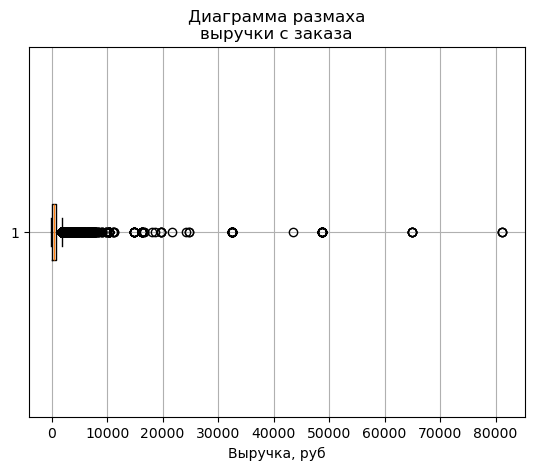

In [15]:
plt.boxplot(df['revenue_rub'], vert = False)
plt.title('Диаграмма размаха\nвыручки с заказа')
plt.xlabel('Выручка, руб')
plt.grid()
plt.show()

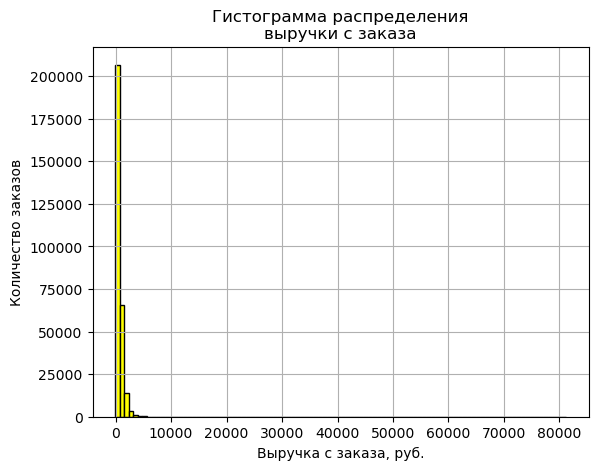

In [16]:
plt.hist(df['revenue_rub'], bins=100, color='yellow', edgecolor='black')

plt.title('Гистограмма распределения\nвыручки с заказа')
plt.xlabel('Выручка с заказа, руб.')
plt.ylabel('Количество заказов')

plt.grid()
plt.show()

In [17]:
q1 = df['revenue_rub'].quantile(0.25)
q3 = df['revenue_rub'].quantile(0.75)
iqr = q3 - q1

upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr

outliers = df[(df['revenue_rub'] < lower_bound) | (df['revenue_rub'] > upper_bound)]

print('Нижняя граница:', lower_bound)
print('Верхняя граница:', upper_bound)
print('Количество выбросов:', len(outliers))
print('Доля выбросов:', len(outliers) / len(df))

Нижняя граница: -918.1499786376953
Верхняя граница: 1834.1699676513672
Количество выбросов: 10449
Доля выбросов: 0.03595528042641194


По статистическим показателям столбца `revenue_rub` видно, что наблюдается правосторонняя асимметрия: среднее значение выше медианы, а максимальное значение существенно превышает 75-й процентиль.  Это подтверждается диаграммой размаха, а гистограмма распределения вовсе мало информативна. По правилу межквартильного размаха потенциальными выбросами считаются значения выше верхней границы. Отрицательные значения также требуют проверки, так как могут соответствовать возвратам.

По условию задачи, если встречаются выбросы, данные по столбцу необходимо отфильтровать по 99-му процентилю:

In [18]:
high_pass = df['revenue_rub'].quantile(0.99)
df = df[df['revenue_rub'] <= high_pass]

Вывод статистических показателей, диаграммы размаха и гистограммы распределения отфильтрованного кейса:

In [19]:
df['revenue_rub'].describe()

count   287786.00
mean       518.03
std        511.97
min        -90.76
25%        111.85
50%        343.85
75%        788.66
max       2628.42
Name: revenue_rub, dtype: float64

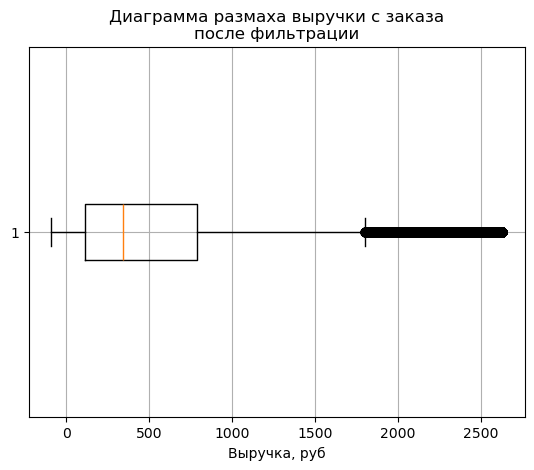

In [20]:
plt.boxplot(df['revenue_rub'], vert = False)
plt.title('Диаграмма размаха выручки с заказа\nпосле фильтрации')
plt.xlabel('Выручка, руб')
plt.grid()
plt.show()

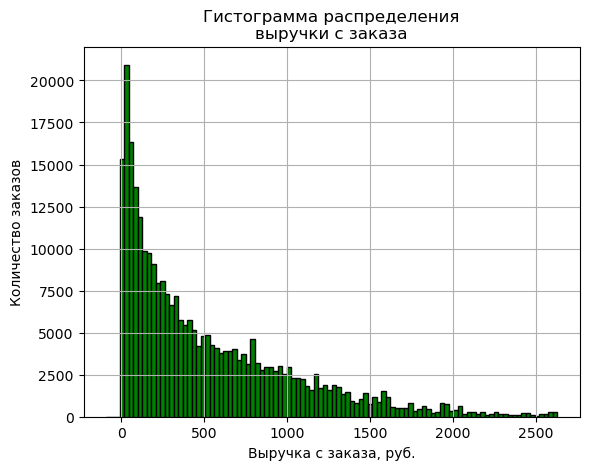

In [21]:
plt.hist(df['revenue_rub'], bins=100, color='green', edgecolor='black')

plt.title('Гистограмма распределения\nвыручки с заказа')
plt.xlabel('Выручка с заказа, руб.')
plt.ylabel('Количество заказов')

plt.grid()
plt.show()

**Промежуточный вывод**

Итог фильтрации выручки с заказа по 99-му процентилю сделал картину более информативной. Распределение остаётся ассиметричным вправо: медиана = 343.85 рублей, что ниже среднего на 174.18. Это подтверждается гистограммой распределения. Для бизнеса это означает, что средний покупатель делает заказ стоимостью около 518 рублей. Сколько же билетов берет средний пользователь за один заказ? Ниже представлена аналитика количества билетов, результаты которой ответят на этот вопрос.

In [22]:
df['tickets_count'].describe()

count   287786.00
mean         2.74
std          1.16
min          1.00
25%          2.00
50%          3.00
75%          3.00
max         57.00
Name: tickets_count, dtype: float64

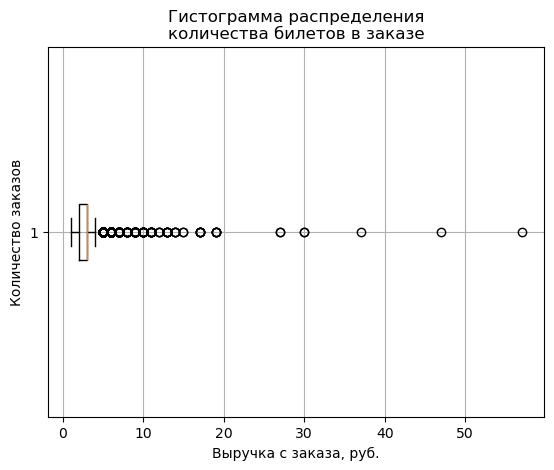

In [23]:
plt.boxplot(df['tickets_count'], vert = False)

plt.title('Гистограмма распределения\nколичества билетов в заказе')
plt.xlabel('Выручка с заказа, руб.')
plt.ylabel('Количество заказов')

plt.grid()
plt.show()

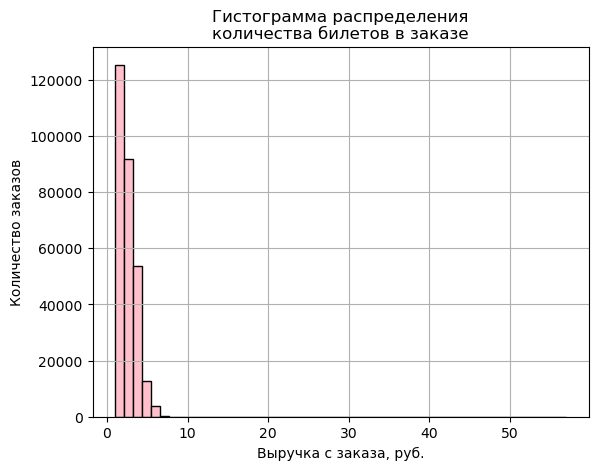

In [24]:
plt.hist(df['tickets_count'], bins=50, color='pink', edgecolor='black')

plt.title('Гистограмма распределения\nколичества билетов в заказе')
plt.xlabel('Выручка с заказа, руб.')
plt.ylabel('Количество заказов')

plt.grid()
plt.show()

In [25]:
q1 = df['tickets_count'].quantile(0.25)
q3 = df['tickets_count'].quantile(0.75)
iqr = q3 - q1

upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr

outliers = df[(df['tickets_count'] < lower_bound) | (df['tickets_count'] > upper_bound)]

print('Нижняя граница:', lower_bound)
print('Верхняя граница:', upper_bound)
print('Количество выбросов:', len(outliers))
print('Доля выбросов:', len(outliers) / len(df))

Нижняя граница: 0.5
Верхняя граница: 4.5
Количество выбросов: 16983
Доля выбросов: 0.05901259964001029


Распределение количества билетов в заказе сосредоточено вокруг 2–3 билетов: медиана равна 3, межквартильный диапазон составляет от 2 до 3 билетов. При этом максимальное значение равно 57, что существенно превышает типичный диапазон и может указывать на групповые заказы или аномальные наблюдения. В таком случае сделаем фильтр количества билетов за заказ по 99-му процентилю.

In [26]:
high_pass = df['tickets_count'].quantile(0.99)
df = df[df['tickets_count'] <= high_pass]

In [27]:
df['tickets_count'].describe()

count   287606.00
mean         2.74
std          1.14
min          1.00
25%          2.00
50%          3.00
75%          3.00
max          6.00
Name: tickets_count, dtype: float64

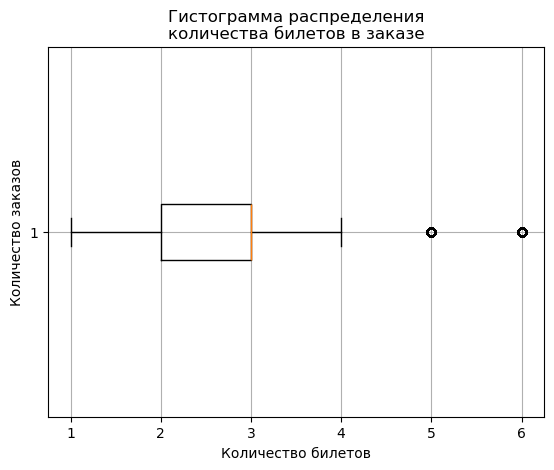

In [28]:
plt.boxplot(df['tickets_count'], vert = False)

plt.title('Гистограмма распределения\nколичества билетов в заказе')
plt.xlabel('Количество билетов')
plt.ylabel('Количество заказов')

plt.grid()
plt.show()

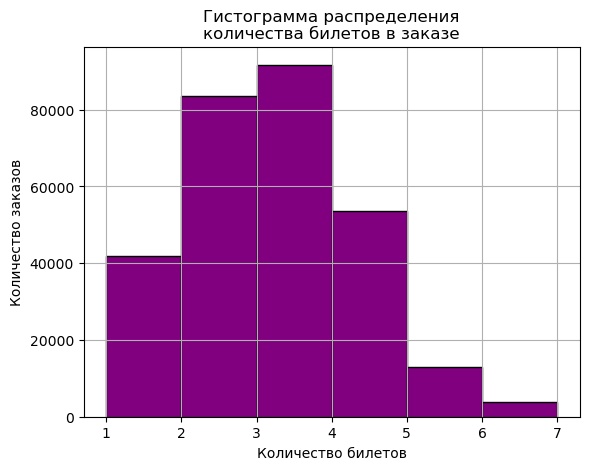

In [29]:
plt.hist(df['tickets_count'], bins=range(1, int(df['tickets_count'].max()) + 2), color='purple', edgecolor='black')

plt.title('Гистограмма распределения\nколичества билетов в заказе')
plt.xlabel('Количество билетов')
plt.ylabel('Количество заказов')

plt.grid()
plt.show()

Сравним общую информацию исходного датафрейма с предобработанным:

In [30]:
# Исходный датафрейм
tmp.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   user_id                290611 non-null  str    
 1   device_type_canonical  290611 non-null  str    
 2   order_id               290611 non-null  int64  
 3   order_dt               290611 non-null  str    
 4   order_ts               290611 non-null  str    
 5   currency_code          290611 non-null  str    
 6   revenue                290611 non-null  float64
 7   tickets_count          290611 non-null  int64  
 8   days_since_prev        268678 non-null  float64
 9   event_id               290611 non-null  int64  
 10  event_name             290611 non-null  str    
 11  event_type_main        290611 non-null  str    
 12  service_name           290611 non-null  str    
 13  region_name            290611 non-null  str    
 14  city_name              290611 non-null  str    

In [31]:
# Предобработанный датафрейм
df.info()

<class 'pandas.DataFrame'>
Index: 287606 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype        
---  ------                 --------------   -----        
 0   user_id                287606 non-null  str          
 1   device_type_canonical  287606 non-null  str          
 2   order_id               287606 non-null  int64        
 3   order_dt               287606 non-null  datetime64[s]
 4   order_ts               287606 non-null  datetime64[s]
 5   currency_code          287606 non-null  str          
 6   revenue                287606 non-null  float32      
 7   tickets_count          287606 non-null  int64        
 8   days_since_prev        265891 non-null  float32      
 9   event_id               287606 non-null  int64        
 10  event_name             287606 non-null  str          
 11  event_type_main        287606 non-null  str          
 12  service_name           287606 non-null  str          
 13  region_name    

Из результатов оптимизации памяти видно, что изменение типов данных и фильтрация положительно сказались на весе датафрейма. Оптимизированный датафрейм сэкономил 7.5 МБ памяти.

**Промежуточный вывод**

В результате выполнения **шага 2** были решены следующие задачи:
1. Реализован перевод выручки с заказов, сделаных в валюте казахстанского тенге, в рублевой эквивалент.
2. Был преобразован тип данных столбцов времени в тип данных datetime64[s], в два раза уменьшена разрядность типов данных `float` с 64-х до 32-х бит.
3. Изучены значения в ключевых столбцах:
   - Проверка категориальных полей `device_type_canonical`, `event_type_main` и `service_name` осуществлялась как выгрузка уникальных значений категориальных столбцов. Неявных дубликатов среди категорий обнаружено не было.
   - Проверка распределений численных данных `revenue_rub`, `tickets_count` и наличие в них выбросов. Для этого использовали статистические показатели, гистограммы распределения значений и диаграммы размаха.

Распределения `revenue_rub` и `tickets_count` имеют право ассиметричное распределение с аномально высокими значениями. 
- `revenue_rub`: До фильтрации среднее значение = 555.57 рублей, медиана = 351.14 рублей, среднеквадратичное отклонение = 875.46 рублей, максимальное значение = 81174.54 рублей. После фильтрации среднее значение = 518.03 рублей, медиана = 511.97 рублей, среднеквадратичное отклонение = 343.85 рублей, максимальное значение = 2628.42 рублей.
- `tickets_count`: До фильтрации среднее значение = 2.74 штук, медиана = 3.00 штук, среднеквадратичное отклонение = 1.16 штук, максимальное значение = 57.00 штук. После фильтрации среднее значение = 2.74 штук, медиана = 3.00 штук, среднеквадратичное отклонение 1.14 штук, максимальное значение= 6.00 штук.

Фильтрация обоих столбцов осуществлялась по 99-му процентилю. Итого получается, что средний заказчик билетов делает заказ на сумму около 500 рублей и берет около 3-х билетов. Стоит отдельно отметить, что в столбце выручки с заказа обнаружены отрицательные значения. Это могут быть возвраты. 

В заключение предобработки были проведены сравнения датафреймов - вес исходного датафрейма составляет 83.3 МБ, приведённого и отфильтрованного = 75.8 МБ. Оптимизация памяти составила 7.5 МБ.

#### Шаг 3. Создание профиля пользователя

В будущем отдел маркетинга планирует создать модель для прогнозирования возврата пользователей. Поэтому сейчас они просят вас построить агрегированные признаки, описывающие поведение и профиль каждого пользователя.

**Задача 3.1.** Построить профиль пользователя - для каждого пользователя найти:
- дату первого и последнего заказа;
- устройство, с которого был сделал первый заказ;
- регион, в котором был сделан первый заказ;
- билетного партнёра, к которому обращались при первом заказе;
- жанр первого посещённого мероприятия (использовав поле `event_type_main`);
- Общее количество заказов;
- средняя выручка с одного заказа в рублях;
- среднее количество билетов в заказе;
- среднее время между заказами.
После этого добавить еще два бинарных признака:
- `is_two` - совершил ли пользователь два и более заказа;
- `is_five` - совершил ли пользователь 5 и более заказов.

Рекомендация: перед тем, как строить профиль, отсортируйте данные по времени совершения заказа.

**Решение 3.1.**

Для решения данной задачи необходимо создать отдельный датафрейм профиля пользователя по агрегированных данным. Решение задачи начнём с выполнения рекомендации, серии датафрейма присоединять последовательно.

In [32]:
# Сортировка данных по времени совершённого заказа order_ts
df = df.sort_values('order_ts', ascending = True)

# Создание нового датафрейма profile_df
# Создание профиля пользователя
profile_df = (
    df.groupby('user_id')
    .agg(
        first_order=('order_ts', 'min'),
        last_order=('order_ts', 'max'),
        first_device=('device_type_canonical', 'first'),
        first_region=('region_name', 'first'),
        first_service=('service_name', 'first'),
        first_event_type=('event_type_main', 'first'),
        orders_count=('order_id', 'count'),
        avg_revenue=('revenue_rub', 'mean'),
        avg_tickets=('tickets_count', 'mean'),
        avg_days_prev=('days_since_prev', 'mean')
        
    )
    .reset_index()
)

profile_df['is_two'] = profile_df['orders_count'] >=2
profile_df['is_five'] = profile_df['orders_count'] >=5

profile_df

,user_id,first_order,last_order,first_device,first_region,first_service,first_event_type,orders_count,avg_revenue,avg_tickets,avg_days_prev,is_two,is_five
0,0002849b70a3ce2,2024-08-20 16:08:03,2024-08-20 16:08:03,mobile,Каменевский регион,Край билетов,театр,1,1521.94,4.00,NaN,False,False
1,0005ca5e93f2cf4,2024-07-23 18:36:24,2024-10-06 13:56:02,mobile,Каменевский регион,Мой билет,выставки,2,774.01,3.00,75.00,True,False
2,000898990054619,2024-07-13 19:40:48,2024-10-23 15:12:00,mobile,Североярская область,Лови билет!,другое,3,767.21,2.67,51.00,True,False
3,00096d1f542ab2b,2024-08-15 16:48:48,2024-08-15 16:48:48,desktop,Каменевский регион,Край билетов,театр,1,917.83,4.00,NaN,False,False
4,000a55a418c128c,2024-09-29 19:39:12,2024-10-15 10:29:04,mobile,Поленовский край,Лучшие билеты,театр,2,61.31,1.50,16.00,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21842,fff13b79bd47d7c,2024-07-16 22:17:10,2024-10-31 18:31:52,mobile,Каменевский регион,Мой билет,другое,9,688.04,2.56,13.38,True,True
21843,fff32fc9ad0f9f6,2024-08-15 14:36:28,2024-10-28 23:40:38,desktop,Каменевский регион,Билеты без проблем,стендап,2,850.99,2.50,74.00,True,False
21844,fffcd3dde79eb2c,2024-06-20 19:57:25,2024-10-30 13:37:43,desktop,Каменевский регион,Билеты без проблем,концерты,33,557.91,2.79,4.12,True,True
21845,fffeeb3c120cf0b,2024-09-24 10:07:42,2024-09-24 10:07:42,desktop,Широковская область,Билеты без проблем,стендап,1,661.53,2.00,NaN,False,False


**Задача 3.2.** Прежде чем проводить исследовательский анализ данных и делать выводы, важно понять, с какими данными мы работаем: насколько они репрезентативны и нет ли в них аномалий.

Используя данные о профилях пользователей, рассчитать:
- общее число пользователей в выборке;
- среднюю выручку с одного заказа;
- долю пользователей, совершивших 2 и более заказа;
- долю пользователей, совершивших 5 и более заказов;

Также изучить статистические показатели:
- по общему числу заказов;
- по среднему числу билетов в заказе;
- по среднему количеству дней между покупками.
По результатам оценить данные: достаточно ли их по объёму, есть ли аномальные значения в данных о количестве заказов и среднем количессве билетов?

Если найдутся аномальные значения, будет необходимо их описать и принять обоснованные решение о том, как с ними поступить:
- Оставить и учитывать при анализе?
- Отфильтровать данные по какому-то значению, например по95-му или 99-му процентилю?

Проведя фильтрацию, вычислить объём отфильтрованные данныз и вывести статистические показатели по обоснованному датасету.

**Решение 3.2.**

Расчёт показателей по таблице профилей пользователей:

In [33]:
# Рассчитанные данные по всей таблице profile_df
print(f'Общее число пользователей в выборке: {len(profile_df['user_id'].unique())}')
print(f'Средняя выручка с одного заказа: {profile_df['avg_revenue'].mean()}')
print(f'Доля пользователей, совершивших 2 и более заказа: {profile_df['is_two'].sum() / profile_df.shape[0]}')
print(f'Доля пользователей, совершивших 5 и более заказов: {profile_df['is_five'].sum() / profile_df.shape[0]}')

Общее число пользователей в выборке: 21847
Средняя выручка с одного заказа: 544.1610107421875
Доля пользователей, совершивших 2 и более заказа: 0.6170183549228727
Доля пользователей, совершивших 5 и более заказов: 0.29006270883874213


Расчёт статистических показателей.

Статичтические показатели общего количества заказов:

In [34]:
profile_df['orders_count'].describe()

count   21847.00
mean       13.16
std       121.58
min         1.00
25%         1.00
50%         2.00
75%         5.00
max     10168.00
Name: orders_count, dtype: float64

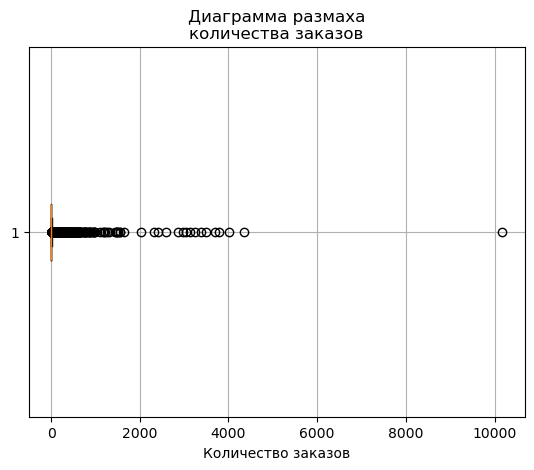

In [35]:
plt.boxplot(profile_df['orders_count'], vert = False)

plt.title('Диаграмма размаха\nколичества заказов')
plt.xlabel('Количество заказов')

plt.grid()
plt.show()

В статистических показателях количества заказов максимальное значение сильно как от средего, так и от выбросов. Причём это не аномальный рост, а лишь значение одного пользователя. В промежутке от 2000 до 4000 заказов наблюдается малая плотность выбросов, по сравнению с промежутком 0-2000. 

Статистические показатели среднего чиста билетов в заказе:

In [36]:
profile_df['avg_tickets'].describe()

count   21847.00
mean        2.74
std         0.90
min         1.00
25%         2.00
50%         2.75
75%         3.07
max         6.00
Name: avg_tickets, dtype: float64

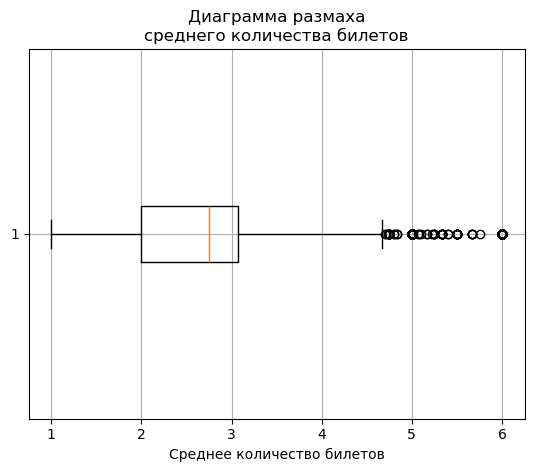

In [37]:
plt.boxplot(profile_df['avg_tickets'], vert = False)

plt.title('Диаграмма размаха\nсреднего количества билетов')
plt.xlabel('Среднее количество билетов')

plt.grid()
plt.show()

Наблюдается малая плотность выбросов по количеству билетов на заказ, превышающих 5. Основная масса пользователей заказывает 2-3 билета.

Статистические показатели по среднему количеству дней между заказами:

In [38]:
profile_df['avg_days_prev'].describe()

count   13516.00
mean       15.82
std        22.28
min         0.00
25%         1.00
50%         8.00
75%        20.33
max       148.00
Name: avg_days_prev, dtype: float64

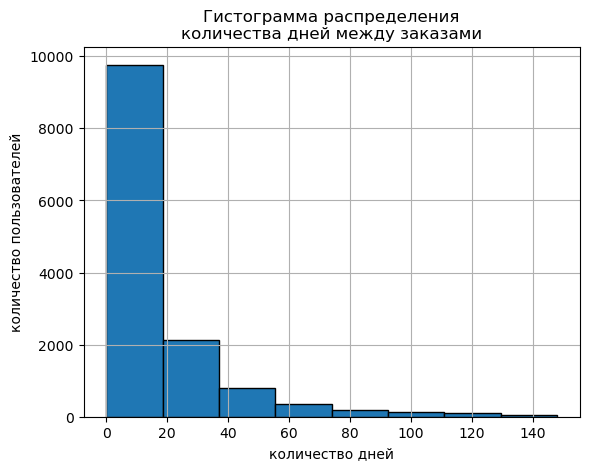

In [39]:
plt.hist(profile_df['avg_days_prev'], bins = 8, edgecolor = 'black')

plt.title('Гистограмма распределения\nколичества дней между заказами')
plt.xlabel('количество дней')
plt.ylabel('количество пользователей')

plt.grid()
plt.show()

**Принятие решения о фильтрации**

Были изучены три распределения: общее количество заказов, количество билетов в одном заказе, среднее количество дней между заказами. Все распределения имеют явную правую ассиметрию.

При изучании статистики общего количества заказов были выявлены выбросы высокой плотности до 2000 заказов, малой плотности до 2000 до 4000 заказов, а также аномальное значение - 10168 заказов. Это может быть связано с техническим тестом Яндекс Афиши. Основная масса значений сосредоточена вокруг среднего ~13 заказов. Данные нуждаются в фильтрации после дополнительного изучения.

Оценка среднего количества билетов выявила выбросы в промежутке от 5 до 6 среднего количества билетов в заказе. Основная масса людей делает заказ на 2-3 билета. Хоть плотность выбросов невелика, покупка 5-ти либо 6-ти билетов - вполне пользовательский кейс. Было принято решение оставить серию как есть, без фильтрации.

Распределение среднего интервала между заказами скошено вправо: большинство повторных пользователей возвращаются в течение нескольких недель, но есть сегмент пользователей с длинными интервалами между заказами. Это отдельная группа людей, которая также важна для учёта при исследовании.

**Дополнительное исследование и фильтрация**

Провёл дополнительное исследование поля `orders_count`. Исследование направлено на подробный осмотр значений верхних процентилей и отображению топ пользователей.

In [40]:
# Сделаем копью датафрейма профилей перед всякими действиями
profile_tmp = profile_df.copy()

In [41]:
# Проверка верхних процентилей
profile_df['orders_count'].quantile([0.90, 0.95, 0.99, 0.995, 0.999])

0.90     15.00
0.95     31.00
0.99    151.54
0.99    321.16
1.00   1460.47
Name: orders_count, dtype: float64

In [42]:
profile_df.sort_values('orders_count', ascending=False).head(20)

,user_id,first_order,last_order,first_device,first_region,first_service,first_event_type,orders_count,avg_revenue,avg_tickets,avg_days_prev,is_two,is_five
981,0beb8fc0c0a9ce1,2024-06-01 00:18:28,2024-10-31 23:28:28,mobile,Североярская область,Билеты в руки,концерты,10168,504.58,2.85,0.01,True,True
2053,18e9aead0a393e7,2024-06-01 00:04:54,2024-10-31 23:49:44,mobile,Каменевский регион,Облачко,концерты,4349,494.53,2.78,0.03,True,True
11067,8187dac4be757a0,2024-06-01 10:53:53,2024-10-31 23:30:10,mobile,Берёзовская область,Билеты в руки,концерты,4020,537.24,2.75,0.04,True,True
5411,3ee7dc2e115847f,2024-06-01 09:13:31,2024-10-31 23:42:07,mobile,Каменевский регион,Мой билет,концерты,3789,537.06,2.75,0.04,True,True
10804,7eb4fc207ecc10f,2024-06-01 09:10:33,2024-10-31 23:58:55,mobile,Каменевский регион,Билеты без проблем,театр,3698,541.44,2.89,0.04,True,True
2329,1c2a2133e1df1b4,2024-06-01 08:25:17,2024-10-31 23:51:29,mobile,Североярская область,Реестр,концерты,3501,541.01,2.66,0.04,True,True
6772,4ec8f6429431987,2024-06-01 11:07:36,2024-10-31 23:18:10,mobile,Североярская область,Реестр,концерты,3374,549.69,2.72,0.04,True,True
14759,ad2dc32364ed948,2024-06-01 08:18:34,2024-10-31 23:32:57,mobile,Яблоневская область,Лови билет!,театр,3243,447.24,2.93,0.05,True,True
15496,b54dd0cd81121fc,2024-06-01 02:34:34,2024-10-31 20:59:23,mobile,Берёзовская область,Лови билет!,другое,3138,481.61,2.81,0.05,True,True
17628,cdbc02c6ad8087a,2024-06-01 10:48:07,2024-10-31 23:57:29,mobile,Чистогорская область,Лови билет!,спорт,3035,466.78,2.76,0.05,True,True


Из изучения верхних процентилей видно, что 99.5% пользователей делают до 321 заказа. В топ 20 пользователей по количеству заказов входят пользователи, сделавшие тысячи заказов, что нетипично относительно остальной массы пользователей. Было принято решение делать фильтрацию пл 99.5-му процентилю.

In [43]:
high_pass = profile_df['orders_count'].quantile(0.995)

profile_df = profile_df[profile_df['orders_count'] <= high_pass]

Проверим количество пользователей после фильтрации:

In [44]:
print('Порог:', high_pass)
print('Было пользователей:', len(profile_tmp))
print('Стало пользователей:', len(profile_df))
print('Удалено пользователей:', len(profile_tmp) - len(profile_df))
print('Доля удалённых:', 1 - len(profile_df) / len(profile_tmp))

Порог: 321.1600000000035
Было пользователей: 21847
Стало пользователей: 21737
Удалено пользователей: 110
Доля удалённых: 0.0050350162493706385


**Промежуточный вывод**

На третьем шаге был построен профиль пользователя: для каждого `user_id` были рассчитаны даты первого и последнего заказа, признаки первого заказа — устройство, регион, билетный партнёр и жанр мероприятия, а также агрегированные поведенческие показатели: общее количество заказов, средняя выручка с заказа, среднее количество билетов и среднее время между заказами. Дополнительно были созданы бинарные признаки `is_two` и `is_five`, показывающие, совершил ли пользователь два и более заказов и пять и более заказов соответственно.

В выборке представлены 21 847 пользователей. Доля пользователей, совершивших два и более заказа, составляет около 61.7%, а доля пользователей с пятью и более заказами — около 29.0%. Это говорит о том, что в данных есть заметная группа повторных пользователей, что важно для дальнейшего анализа возврата пользователей.

При изучении распределения количества заказов на пользователя были обнаружены выраженные аномальные значения. Медианное количество заказов равно 2, а 75% пользователей сделали не более 5 заказов. При этом максимальное значение достигает 10 168 заказов, что существенно отличается от поведения основной массы пользователей и может соответствовать техническим, корпоративным или иным нетипичным аккаунтам. Такие значения сильно искажают среднее и стандартное отклонение, поэтому для дальнейшего анализа массового пользовательского поведения была выполнена фильтрация по верхнему 99-му процентилю признака `orders_count`.

После фильтрации было удалено 110 пользователей, то есть около 0.5% выборки. В отфильтрованном датафрейме осталось 21 414 пользователей. Такой подход позволяет сохранить почти всю пользовательскую базу, но снизить влияние экстремально активных пользователей на дальнейшие выводы.

Распределение среднего количества билетов в заказе выглядит более устойчивым: большинство пользователей в среднем покупают около 2–3 билетов, а максимальное значение равно 6. Поэтому дополнительная фильтрация по этому признаку не требуется. Признак `avg_days_prev` рассчитан только для пользователей с повторными заказами, поэтому наличие пропусков в нём является ожидаемым и не требует удаления строк: для пользователей с одним заказом средний интервал между заказами определить невозможно.

Таким образом, на **шаге 3** был сформирован рабочий датафрейм профилей пользователей, пригодный для дальнейшего исследовательского анализа признаков, связанных с повторными заказами и удержанием пользователей.

#### Шаг 4. Исследовательский анализ данных
Следующий этап — исследование признаков, влияющих на возврат пользователей, то есть на совершение повторного заказа. Для этого используйте профили пользователей.

**4.1. Исследование признаков первого заказа и их связи с возвращением на платформу**

Исследуйте признаки, описывающие первый заказ пользователя, и выясните, влияют ли они на вероятность возвращения пользователя.

**Задача 4.1.1.**

Изучите распределение пользователей по признакам.

Сгруппируйте пользователей:
- по типу их первого мероприятия;
- по типу устройства, с которого совершена первая покупка;
- по региону проведения мероприятия из первого заказа;
- по билетному оператору, продавшему билеты на первый заказ.
- 
Подсчитайте общее количество пользователей в каждом сегменте и их долю в разрезе каждого признака. Сегмент — это группа пользователей, объединённых определённым признаком, то есть объединённые принадлежностью к категории. Например, все клиенты, сделавшие первый заказ с мобильного телефона, — это сегмент.

Ответьте на вопрос: равномерно ли распределены пользователи по сегментам или есть выраженные «точки входа» — сегменты с наибольшим числом пользователей?


**Решение 4.1.1.**

Для решения этой задачи полезной стратегией является написание отдельной универсальной пользовательской функции, применяемой ко всем признакам первых заказов пользователей.

In [45]:
# Функция сегментации
def get_segment_distribution(data, segment_col):
    result = (
        data.groupby(segment_col)
        .agg(users_count=('user_id', 'nunique'))
        .reset_index()
    )

    result['users_share'] = result['users_count'] / result['users_count'].sum()
    result['users_share_pct'] = (result['users_share'] * 100).round(2)

    return result.sort_values('users_count', ascending = False)

In [46]:
# Применение на признаках
event_type_segments = get_segment_distribution(profile_df, 'first_event_type')
device_segments = get_segment_distribution(profile_df, 'first_device')
region_segments = get_segment_distribution(profile_df, 'first_region')
service_segments = get_segment_distribution(profile_df, 'first_service')

Ниже просмотрим сегменты по каждому признаку.

Признак первого типа мероприятия:

In [47]:
# Просмотр сегментов
event_type_segments

,first_event_type,users_count,users_share,users_share_pct
2,концерты,9609,0.44,44.21
1,другое,5442,0.25,25.04
5,театр,4265,0.20,19.62
4,стендап,1114,0.05,5.12
3,спорт,798,0.04,3.67
0,выставки,414,0.02,1.90
6,ёлки,95,0.00,0.44


Признак девайса, с которого был сделан первый заказ:

In [48]:
device_segments

,first_device,users_count,users_share,users_share_pct
1,mobile,18004,0.83,82.83
0,desktop,3733,0.17,17.17


Топ-10 регионов по количеству пользователей, следавших первый заказ:

In [49]:
region_segments.head(10)

,first_region,users_count,users_share,users_share_pct
23,Каменевский регион,7122,0.33,32.76
60,Североярская область,3778,0.17,17.38
77,Широковская область,1229,0.06,5.65
45,Озернинский край,677,0.03,3.11
41,Малиновоярский округ,527,0.02,2.42
76,Шанырский регион,502,0.02,2.31
74,Травяная область,491,0.02,2.26
57,Светополянский округ,458,0.02,2.11
52,Речиновская область,445,0.02,2.05
78,Яблоневская область,413,0.02,1.90


Топ-10 билетных операторов по количеству пользователей, следавших первый заказ:

In [50]:
service_segments.head(10)

,first_service,users_count,users_share,users_share_pct
3,Билеты без проблем,5199,0.24,23.92
22,Мой билет,2984,0.14,13.73
19,Лови билет!,2827,0.13,13.01
4,Билеты в руки,2573,0.12,11.84
23,Облачко,2185,0.10,10.05
7,Весь в билетах,1293,0.06,5.95
20,Лучшие билеты,1185,0.05,5.45
24,Прачечная,585,0.03,2.69
17,Край билетов,454,0.02,2.09
12,Дом культуры,358,0.02,1.65


Ниже приведена визуализация распределения сегментов по каждому признаку. 

Визуализация признака первого типа мероприятия:

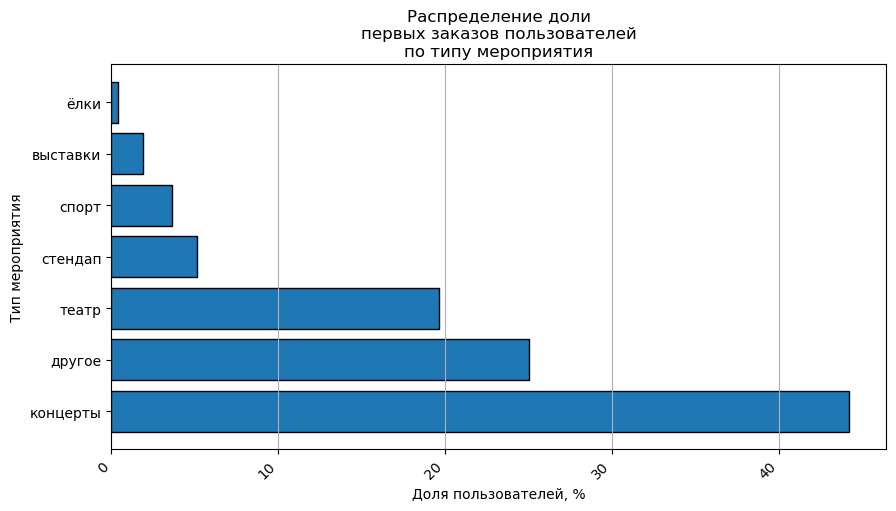

In [51]:
plt.figure(figsize=(10, 5))

plt.barh(
    event_type_segments['first_event_type'],
    event_type_segments['users_share_pct'],
    edgecolor='black'
)

plt.title('Распределение доли\nпервых заказов пользователей\nпо типу мероприятия')
plt.xlabel('Доля пользователей, %')
plt.ylabel('Тип мероприятия')

plt.xticks(rotation=45, ha='right')
plt.grid(axis='x')
plt.show()

Распределение неравномерное с явно выраженным лидером категории мероприятия - концерты. Более подробно это и другие распределения обсудим в промежуточном выводе по задаче.

Визуализация распределения по признаку девайса, с которого был сделан первый заказ:

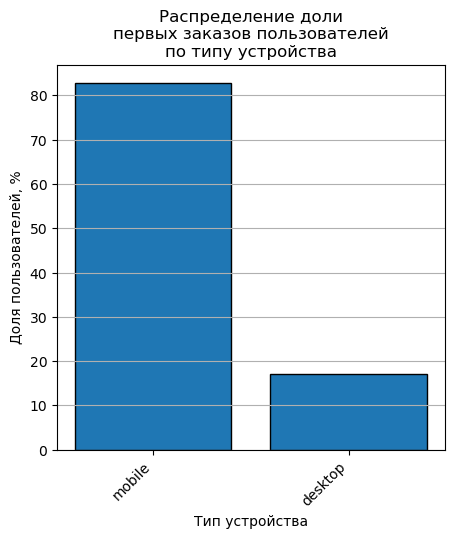

Также выявлен ярко выраженный лидер по типу стройства. С мобильного телефона первый заказ был сделан в 4.82 раз больше, чем с компьютера.


In [52]:
plt.figure(figsize=(5, 5))

plt.bar(
    device_segments['first_device'],
    device_segments['users_share_pct'],
    edgecolor='black'
)

plt.title('Распределение доли\nпервых заказов пользователей\nпо типу устройства')
plt.xlabel('Тип устройства')
plt.ylabel('Доля пользователей, %')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.show()

mobile_count = device_segments.loc[
    device_segments['first_device'] == 'mobile', 
    'users_count'
].iloc[0]

desktop_count = device_segments.loc[
    device_segments['first_device'] == 'desktop', 
    'users_count'
].iloc[0]

mobile_count / desktop_count
ratio = mobile_count / desktop_count

print(f'Также выявлен ярко выраженный лидер по типу стройства. С мобильного телефона первый заказ был сделан в {ratio:.2f} раз больше, чем с компьютера.')

Визуализация топ-10 регионов по количеству пользователей, следавших первый заказ:

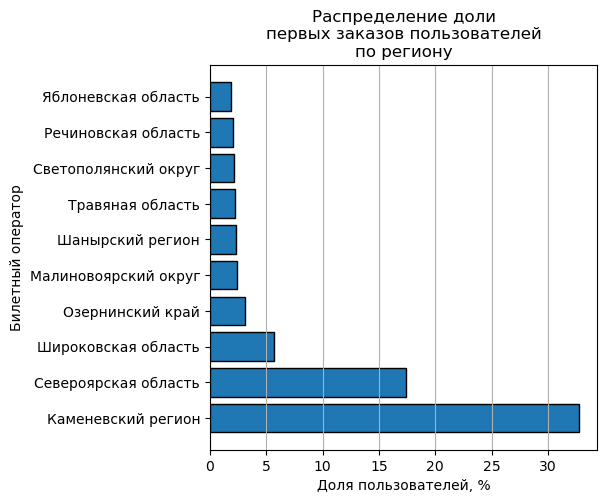

In [53]:
plt.figure(figsize=(5, 5))

plt.barh(
    region_segments['first_region'].head(10),
    region_segments['users_share_pct'].head(10),
    edgecolor='black'
)

plt.title('Распределение доли\nпервых заказов пользователей\nпо региону')
plt.xlabel('Доля пользователей, %')
plt.ylabel('Билетный оператор')
plt.grid(axis='x')
plt.show()

Выявлен явный лидер - более 30% от всех первых заказов совершается в Каменевском районе.

Визуализация топ-10 билетных операторов по количеству пользователей, следавших первый заказ:

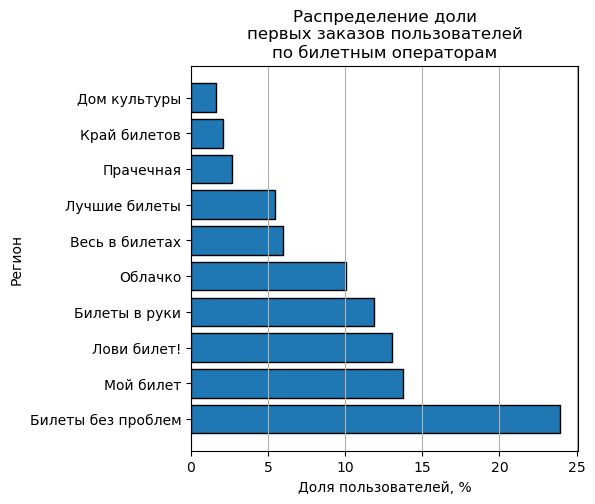

In [54]:
plt.figure(figsize=(5, 5))

plt.barh(
    service_segments['first_service'].head(10),
    service_segments['users_share_pct'].head(10),
    edgecolor='black'
)

plt.title('Распределение доли\nпервых заказов пользователей\nпо билетным операторам')
plt.xlabel('Доля пользователей, %')
plt.ylabel('Регион')
plt.grid(axis='x')
plt.show()

Первый заказ в более чем 20% случаем делается у билетного оператора "Билеты без проблем"

**Промежуточный вывод**

В процессе решения задачи было произведено сегментирование пользователей по четырем признакам: `event_type_segments` - признак первого мероприятия, `device_segments` - признак первого девайса, `region_segments` - признак первого региона, `service_segments` - признак первого билетного оператора.

Сегментирование пользователей по всем предложенным в данной задаче пользователям неравномерное, с явно выраженными лидерами.
- `event_type_segments`: Явным лидером по колчеству первых заказов является сегмент "концерты" - 44% пользователей. На втором месте сегмент "другое" - 25% пользователей. На третьем месте - "театр" с около 20% пользователей.
- `device_segments`: В выборке представлены два сегмента - "mobile" (мобильный телефон) и "desktop" (персональный компьютер). Число пользователей mobile-сегмента почти в 5 раз выше числа пользователей сегмента с персональным компьютером! Количество первых заказов с мобильного составляет 18 тыс, что делает этот сегмент "точкой входа" для бизнес стратегий.
- `region_segments`: Количество пользователей, делающих первый заказ в Каменевском районе среди прочих больше всего - порядка 7 тысяч человек (33%). На втором месте Североярская область - 3778 человек или порядка 17%. Сильно отстаёт от них третье место - Широковская область с 1229 заказами или 6%.
- `service_segments`: Лидером среди операторов является "Билеты без проблем" - почти 24% пользователей, делающих свой первый заказ, предпочитают его. Возможно это также связано с масштабностью событий, на которые этот оператор продаёт билеты. Участок распределения со второго места по пятое можно считать квазиравномерным, от сегмента к сегменту процентиль медленно меняется с 14% до 10%. Но общая тенденция всё же неравномерная.

Данная задача имеет полезное решение для бизнеса: теперь есть возможность построить портрет пользователя, делающего первых заказ. 

Таким образом, наиболее типичный сценарий первого заказа выглядит следующим образом: пользователь из Каменевского района делает заказ с мобильного устройства, выбирает концерт и оформляет покупку через билетного оператора «Билеты без проблем». Эти сегменты можно рассматривать как ключевые точки входа пользователей и учитывать при дальнейшем анализе пользовательского поведения и бизнес-стратегии.

**Задача 4.1.2.** 

Проанализируйте возвраты пользователей:

Для каждого сегмента вычислите долю пользователей, совершивших два и более заказа.
Визуализируйте результат подходящим графиком. Если сегментов слишком много, то поместите на график только 10 сегментов с наибольшим количеством пользователей. Такое возможно с сегментами по региону и по билетному оператору.

Ответьте на вопросы:

- Какие сегменты пользователей чаще возвращаются на Яндекс Афишу?
- Наблюдаются ли успешные «точки входа» — такие сегменты, в которых пользователи чаще совершают повторный заказ, чем в среднем по выборке?

При интерпретации результатов учитывайте размер сегментов: если в сегменте мало пользователей (например, десятки), то доли могут быть нестабильными и недостоверными, то есть показывать широкую вариацию значений.

**Решение 4.1.2.**

Сначала раcсчитаем среднюю долю пользователей в целом по всей выборке, затем рассмотрим каждый признак.

В целом по выборке:

In [55]:
avg_return_rate_pct = profile_df['is_two'].mean() * 100

avg_return_rate_pct

np.float64(61.5080277867231)

1. Возвраты по типу первого мероприятия:

In [56]:
event_type_returns = (
    profile_df
    .groupby('first_event_type')
    .agg(
        users_count=('user_id', 'nunique'),
        returned_users=('is_two', 'sum'),
        return_rate=('is_two', 'mean')
    )
    .reset_index()
)

event_type_returns['return_rate_pct'] = (
    event_type_returns['return_rate'] * 100
).round(2)

event_type_returns = event_type_returns.sort_values('return_rate_pct', ascending=False)

event_type_returns

,first_event_type,users_count,returned_users,return_rate,return_rate_pct
0,выставки,414,265,0.64,64.01
5,театр,4265,2713,0.64,63.61
2,концерты,9609,5960,0.62,62.03
4,стендап,1114,680,0.61,61.04
1,другое,5442,3252,0.60,59.76
3,спорт,798,447,0.56,56.02
6,ёлки,95,53,0.56,55.79


Визуализация:

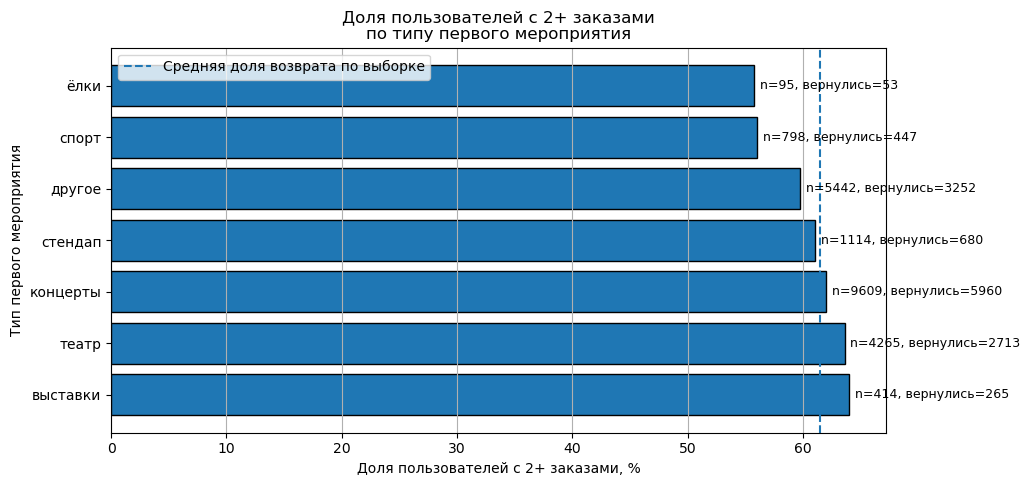

In [57]:
plt.figure(figsize=(10, 5))

bars = plt.barh(
    event_type_returns['first_event_type'],
    event_type_returns['return_rate_pct'],
    edgecolor='black'
)
plt.axvline(
    avg_return_rate_pct,
    linestyle='--',
    label='Средняя доля возврата по выборке'
)
for bar, users_count, returned_users in zip(
    bars,
    event_type_returns['users_count'],
    event_type_returns['returned_users']
):
    width = bar.get_width()
    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'n={users_count}, вернулись={returned_users}',
        va='center',
        fontsize=9
    )

plt.title('Доля пользователей с 2+ заказами\nпо типу первого мероприятия')
plt.xlabel('Доля пользователей с 2+ заказами, %')
plt.ylabel('Тип первого мероприятия')

plt.legend()
plt.grid(axis='x')
plt.show()

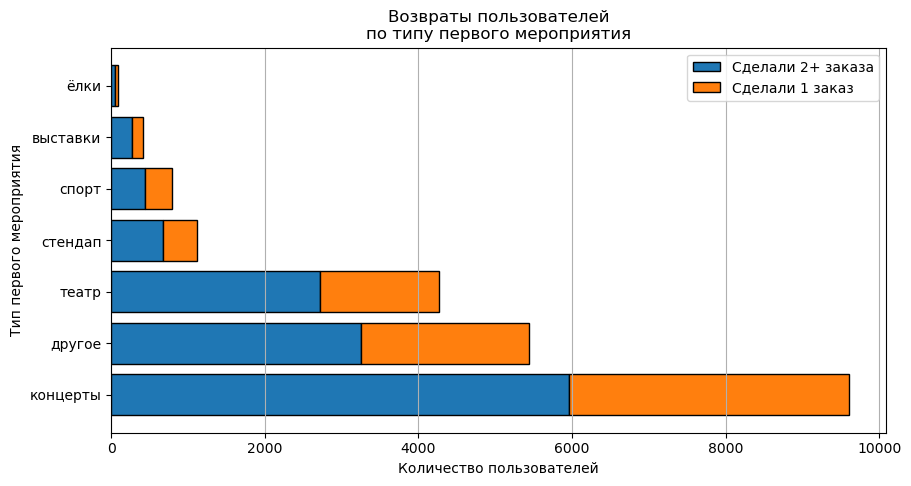

In [58]:
event_type_returns_abs = event_type_returns.copy()

event_type_returns_abs['not_returned_users'] = (
    event_type_returns_abs['users_count'] - event_type_returns_abs['returned_users']
)

event_type_returns_abs = event_type_returns_abs.sort_values('users_count', ascending=False)

plt.figure(figsize=(10, 5))

plt.barh(
    event_type_returns_abs['first_event_type'],
    event_type_returns_abs['returned_users'],
    edgecolor='black',
    label='Сделали 2+ заказа'
)

plt.barh(
    event_type_returns_abs['first_event_type'],
    event_type_returns_abs['not_returned_users'],
    left=event_type_returns_abs['returned_users'],
    edgecolor='black',
    label='Сделали 1 заказ'
)

plt.title('Возвраты пользователей\nпо типу первого мероприятия')
plt.xlabel('Количество пользователей')
plt.ylabel('Тип первого мероприятия')

plt.legend()
plt.grid(axis='x')
plt.show()

2. Возвраты по устройству первого заказа:

In [59]:
device_returns = (
    profile_df
    .groupby('first_device')
    .agg(
        users_count=('user_id', 'nunique'),
        return_rate=('is_two', 'mean')
    )
    .reset_index()
)

device_returns['return_rate_pct'] = (device_returns['return_rate'] * 100).round(2)

device_returns = device_returns.sort_values('return_rate_pct', ascending=False)

device_returns

,first_device,users_count,return_rate,return_rate_pct
0,desktop,3733,0.64,64.05
1,mobile,18004,0.61,60.98


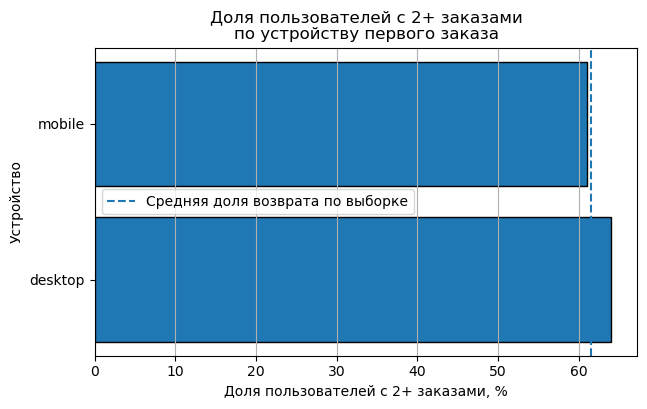

In [60]:
plt.figure(figsize=(7, 4))

plt.barh(
    device_returns['first_device'],
    device_returns['return_rate_pct'],
    edgecolor='black'
)

plt.axvline(
    avg_return_rate_pct,
    linestyle='--',
    label='Средняя доля возврата по выборке'
)

plt.title('Доля пользователей с 2+ заказами\nпо устройству первого заказа')
plt.xlabel('Доля пользователей с 2+ заказами, %')
plt.ylabel('Устройство')

plt.legend()
plt.grid(axis='x')
plt.show()

Доля пользователей, сделавших 2 и более заказа с мобильного устройства чуть ниже среднего значения. Доля пользователей с компьютером чуть выше среднего. Однако в абсолютном масштабе сегмент "mobile" является абсолютным лидером.

3. Возвраты по регионам:

In [61]:
# По всем регионам
region_returns = (
    profile_df
    .groupby('first_region')
    .agg(
        users_count=('user_id', 'nunique'),
        returned_users=('is_two', 'sum'),
        return_rate=('is_two', 'mean')
    )
    .reset_index()
)

region_returns['return_rate_pct'] = (
    region_returns['return_rate'] * 100
).round(2)

region_returns = region_returns.sort_values('users_count', ascending=False)

top_region_returns = region_returns.head(10)

In [62]:
# Топ-10
top_region_returns = region_returns.head(10)

top_region_returns

,first_region,users_count,returned_users,return_rate,return_rate_pct
23,Каменевский регион,7122,4458,0.63,62.59
60,Североярская область,3778,2415,0.64,63.92
77,Широковская область,1229,795,0.65,64.69
45,Озернинский край,677,375,0.55,55.39
41,Малиновоярский округ,527,296,0.56,56.17
76,Шанырский регион,502,338,0.67,67.33
74,Травяная область,491,303,0.62,61.71
57,Светополянский округ,458,301,0.66,65.72
52,Речиновская область,445,284,0.64,63.82
78,Яблоневская область,413,246,0.60,59.56


Визуализация:

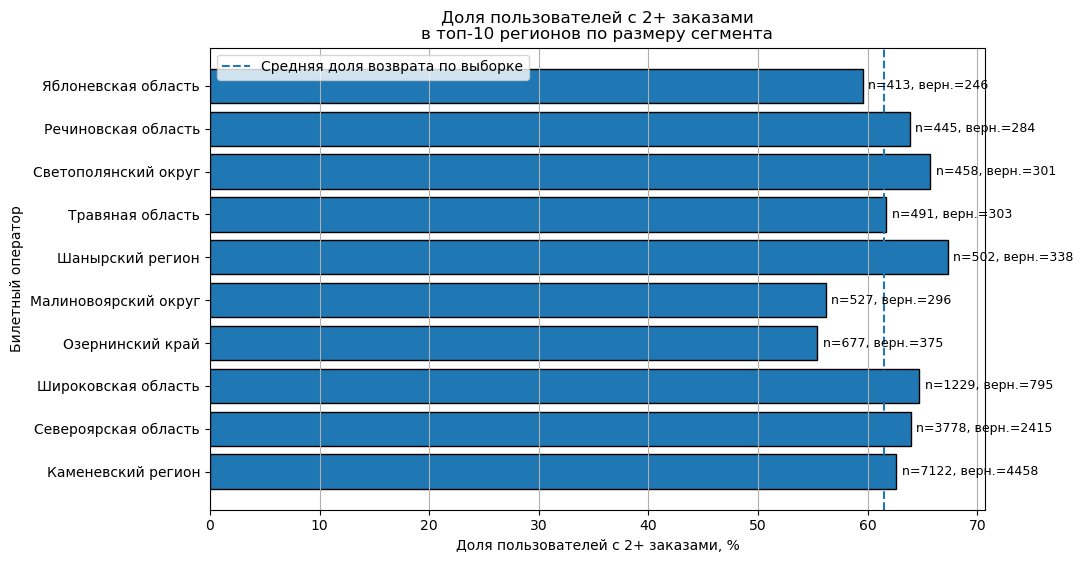

In [63]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_region_returns['first_region'],
    top_region_returns['return_rate_pct'],
    edgecolor='black'
)

plt.axvline(
    avg_return_rate_pct,
    linestyle='--',
    label='Средняя доля возврата по выборке'
)

for bar, users_count, returned_users in zip(
    bars,
    top_region_returns['users_count'],
    top_region_returns['returned_users']
):
    width = bar.get_width()
    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'n={users_count}, верн.={returned_users}',
        va='center',
        fontsize=9
    )

plt.title('Доля пользователей с 2+ заказами\nв топ-10 регионов по размеру сегмента')
plt.xlabel('Доля пользователей с 2+ заказами, %')
plt.ylabel('Билетный оператор')

plt.legend()
plt.grid(axis='x')
plt.show()

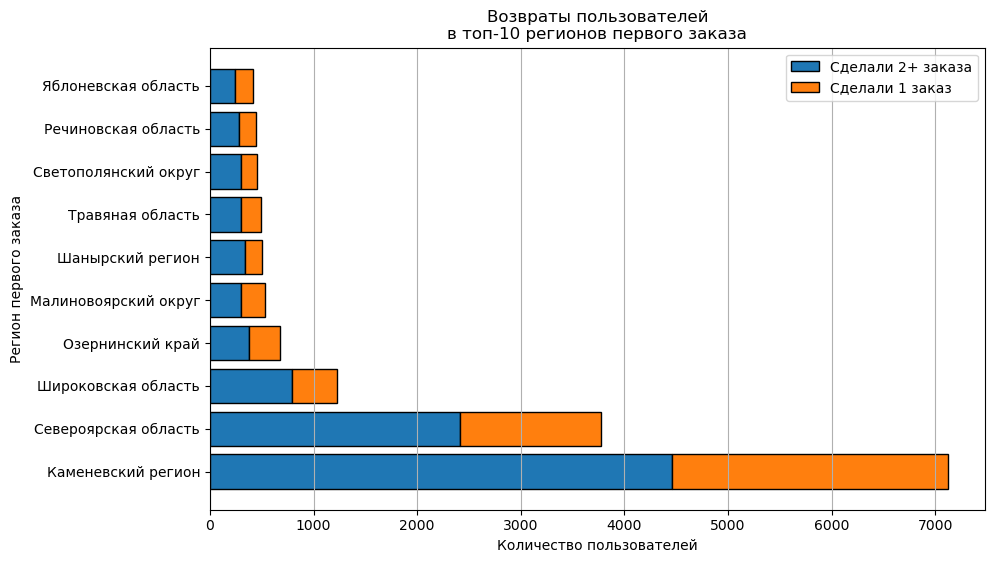

In [64]:
region_returns_abs = region_returns.copy()

region_returns_abs['not_returned_users'] = (
    region_returns_abs['users_count'] - region_returns_abs['returned_users']
)

region_returns_abs = (
    region_returns_abs
    .sort_values('users_count', ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    region_returns_abs['first_region'],
    region_returns_abs['returned_users'],
    edgecolor='black',
    label='Сделали 2+ заказа'
)

plt.barh(
    region_returns_abs['first_region'],
    region_returns_abs['not_returned_users'],
    left=region_returns_abs['returned_users'],
    edgecolor='black',
    label='Сделали 1 заказ'
)

plt.title('Возвраты пользователей\nв топ-10 регионов первого заказа')
plt.xlabel('Количество пользователей')
plt.ylabel('Регион первого заказа')

plt.legend()
plt.grid(axis='x')
plt.show()

Лидером по количеству человек, делающих 2 и более заказа, в относительном масштабе, является Шанырский район. Главное не обманываться, т.к. доля вернувшихся в этом сегменте составляет всего 338 человек из 502. Каменевский район, аналогично предыдущей задаче, лидирует в абсолютном масштабе. Из 7122 человек, сделавших, по меньшей мере, один повторный заказ - 4458. Количество вернувшихся людей превышает общее количество людей из Североярской области.

4. Возвраты по билетному оператору:

In [65]:
# По всем операторам
service_returns = (
    profile_df
    .groupby('first_service')
    .agg(
        users_count=('user_id', 'nunique'),
        returned_users=('is_two', 'sum'),
        return_rate=('is_two', 'mean')
    )
    .reset_index()
)

service_returns['return_rate_pct'] = (service_returns['return_rate'] * 100).round(2)

service_returns = service_returns.sort_values('users_count', ascending=False)

service_returns

,first_service,users_count,returned_users,return_rate,return_rate_pct
3,Билеты без проблем,5199,3149,0.61,60.57
22,Мой билет,2984,1820,0.61,60.99
19,Лови билет!,2827,1729,0.61,61.16
4,Билеты в руки,2573,1619,0.63,62.92
23,Облачко,2185,1342,0.61,61.42
7,Весь в билетах,1293,816,0.63,63.11
20,Лучшие билеты,1185,726,0.61,61.27
24,Прачечная,585,367,0.63,62.74
17,Край билетов,454,296,0.65,65.20
12,Дом культуры,358,232,0.65,64.80


In [66]:
top_service_returns = service_returns.head(10)

top_service_returns

,first_service,users_count,returned_users,return_rate,return_rate_pct
3,Билеты без проблем,5199,3149,0.61,60.57
22,Мой билет,2984,1820,0.61,60.99
19,Лови билет!,2827,1729,0.61,61.16
4,Билеты в руки,2573,1619,0.63,62.92
23,Облачко,2185,1342,0.61,61.42
7,Весь в билетах,1293,816,0.63,63.11
20,Лучшие билеты,1185,726,0.61,61.27
24,Прачечная,585,367,0.63,62.74
17,Край билетов,454,296,0.65,65.20
12,Дом культуры,358,232,0.65,64.80


Визуализация:

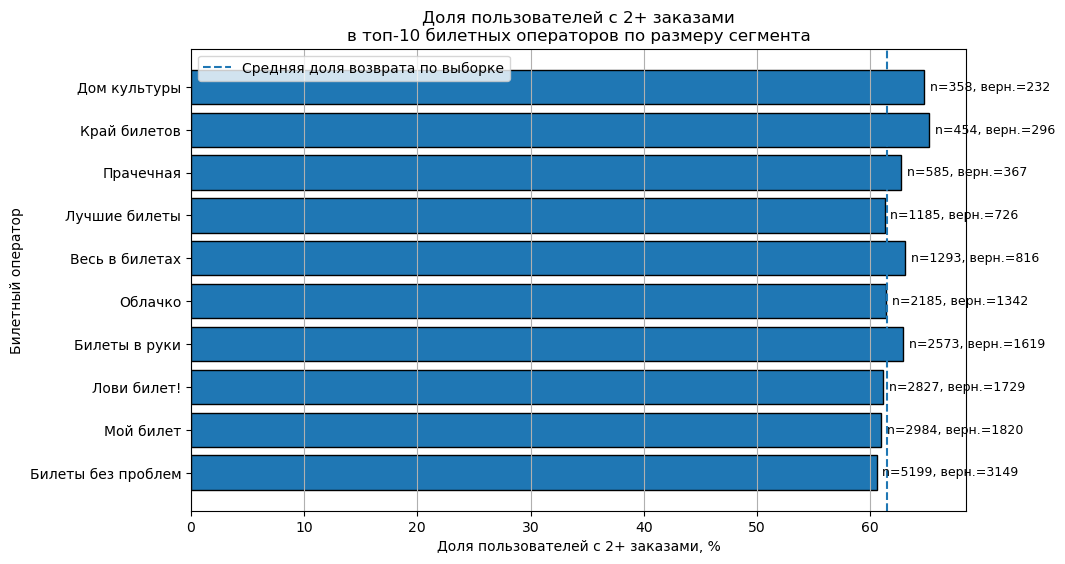

In [67]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_service_returns['first_service'],
    top_service_returns['return_rate_pct'],
    edgecolor='black'
)

plt.axvline(
    avg_return_rate_pct,
    linestyle='--',
    label='Средняя доля возврата по выборке'
)

for bar, users_count, returned_users in zip(
    bars,
    top_service_returns['users_count'],
    top_service_returns['returned_users']
):
    width = bar.get_width()
    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'n={users_count}, верн.={returned_users}',
        va='center',
        fontsize=9
    )

plt.title('Доля пользователей с 2+ заказами\nв топ-10 билетных операторов по размеру сегмента')
plt.xlabel('Доля пользователей с 2+ заказами, %')
plt.ylabel('Билетный оператор')

plt.legend()
plt.grid(axis='x')
plt.show()

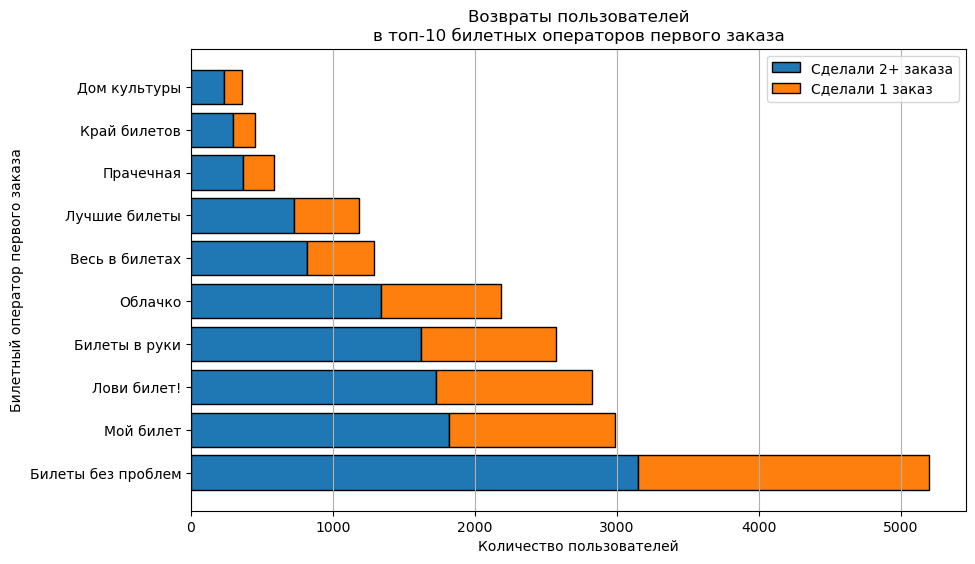

In [68]:
service_returns_abs = service_returns.copy()

service_returns_abs['not_returned_users'] = (
    service_returns_abs['users_count'] - service_returns_abs['returned_users']
)

service_returns_abs = (
    service_returns_abs
    .sort_values('users_count', ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

plt.barh(
    service_returns_abs['first_service'],
    service_returns_abs['returned_users'],
    edgecolor='black',
    label='Сделали 2+ заказа'
)

plt.barh(
    service_returns_abs['first_service'],
    service_returns_abs['not_returned_users'],
    left=service_returns_abs['returned_users'],
    edgecolor='black',
    label='Сделали 1 заказ'
)

plt.title('Возвраты пользователей\nв топ-10 билетных операторов первого заказа')
plt.xlabel('Количество пользователей')
plt.ylabel('Билетный оператор первого заказа')

plt.legend()
plt.grid(axis='x')
plt.show()

Как можно видеть, в относительном масштабе лидирует сегмент оператора "Край билетов". Но главное не делать ложных выводов об этом сегменте как о безоговорочном лидере, так как количество заказов с этого оператора кратно меньше лидеров предыдущей задачи. Оператор "Билеты без проблем" имеет процент возврата меньше среднего в относительном масштабе, но при этом лидирует в абсолюте - количество пользователей, сделавших 2 и более заказа превышает общее количество пользователей сегмента "Мой билет", занявшего второе место.

**Промежуточный вывод**

Для анализа возвратов по сегментам была рассчитана доля пользователей, совершивших два и более заказа. Однако при интерпретации долей важно учитывать размер сегмента: одинаковые проценты могут соответствовать совершенно разному числу пользователей. Поэтому дополнительно были рассчитаны абсолютные значения `users_count` и `returned_users`, а на графиках рядом с долей возврата указан размер сегмента.

В среднем по выборке повторный заказ совершают 61,5% пользователей. При анализе по сегментам видно, что различия в доле возврата присутствуют, но их следует интерпретировать вместе с численностью сегмента.

По типу первого мероприятия выше среднего возвращаются пользователи, начавшие с выставок, театра и концертов, тогда как более низкая доля возврата наблюдается у сегментов спорт и ёлки. По устройству первого заказа различия незначительны: пользователи "desktop" возвращаются немного чаще, чем пользователи "mobile".

Среди регионов разброс значений более заметен: есть как сегменты с долей возврата существенно выше средней, так и сегменты с более низкими показателями. При этом наибольший практический интерес представляют крупные регионы, где доля возврата остаётся на уровне средней или выше неё.

По билетным операторам существенных различий не выявлено: у большинства крупных операторов доля возврата близка к средней по выборке.

Таким образом, в разрезе рассмотренных признаков доля вернувшихся пользователей в большинстве сегментов остаётся примерно на одном уровне — около 60%. Это говорит о том, что выраженных различий в относительных показателях между сегментами не наблюдается, и в целом тенденция возврата пользователей остаётся схожей вне зависимости от признака. Поэтому для интерпретации результатов более полезно опираться не только на доли, но и на абсолютные значения: именно численность пользователей в сегменте и количество вернувшихся пользователей позволяют понять, какие группы действительно вносят наибольший вклад в общее число возвратов.

**Задача 4.1.3.** 

Опираясь на выводы из задач выше, проверьте продуктовые гипотезы:

Гипотеза 1. Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.

Гипотеза 2. В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

**Решение 4.1.3.**

Проверка Гипотезы 1. В ней предлагается изучить влияние типа мероприятия на вероятность возврата на Яндекс Афишу. 

In [69]:
sport_concert_compare = (
    profile_df[profile_df['first_event_type'].isin(['спорт', 'концерты'])]
    .groupby('first_event_type')
    .agg(
        users_count=('user_id', 'nunique'),
        returned_users=('is_two', 'sum'),
        return_rate=('is_two', 'mean')
    )
    .reset_index()
)

sport_concert_compare

,first_event_type,users_count,returned_users,return_rate
0,концерты,9609,5960,0.62
1,спорт,798,447,0.56


Проверка Гипотезы 2. Необходимо подтвердить либо опровергнуть, что в регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

In [70]:
region_returns = (
    profile_df
    .groupby('first_region')
    .agg(
        users_count=('user_id', 'nunique'),
        returned_users=('is_two', 'sum'),
        return_rate=('is_two', 'mean')
    )
    .reset_index()
)

median_users = region_returns['users_count'].median()

region_returns['activity_group'] = np.where(
    region_returns['users_count'] >= median_users,
    'более активные',
    'менее активные'
)

region_returns.groupby('activity_group')['return_rate'].describe()

activity_compare = (
    region_returns
    .groupby('activity_group')
    .agg(
        regions_count=('first_region', 'count'),
        avg_users_count=('users_count', 'mean'),
        median_users_count=('users_count', 'median'),
        avg_return_rate=('return_rate', 'mean'),
        median_return_rate=('return_rate', 'median')
    )
    .reset_index()
)

activity_compare

,activity_group,regions_count,avg_users_count,median_users_count,avg_return_rate,median_return_rate
0,более активные,41,509.93,206.00,0.59,0.59
1,менее активные,40,20.75,21.00,0.52,0.53


**Промежуточный вывод**

Проверка первой гипотезы показала, что она не подтверждается: пользователи, совершившие первый заказ на спортивные мероприятия, возвращаются реже, чем пользователи, начавшие с концертов - 56% против 62%. Следовательно, по имеющимся данным тип первого мероприятия в формулировке гипотезы влияет не так, как предполагалось изначально.

Проверка второй гипотезы показала, что в более активных регионах доля повторных заказов действительно выше, чем в менее активных: среднее значение `return_rate` составляет 0.59 против 0.52, медианное - 0.59 против 0.53. Это позволяет считать гипотезу подтверждённой.

**4.2. Исследование поведения пользователей через показатели выручки и состава заказа**

Изучите количественные характеристики заказов пользователей, чтобы узнать среднюю выручку сервиса с заказа и количество билетов, которое пользователи обычно покупают.

Эти метрики важны не только для оценки выручки, но и для оценки вовлечённости пользователей. Возможно, пользователи с более крупными и дорогими заказами более заинтересованы в сервисе и поэтому чаще возвращаются.

**Задача 4.2.1.**

Проследите связь между средней выручкой сервиса с заказа и повторными заказами.
- Постройте сравнительные гистограммы распределения средней выручки с билета:
для пользователей, совершивших один заказ;
для вернувшихся пользователей, совершивших 2 и более заказа.
- Ответьте на вопросы: 
  - В каких диапазонах средней выручки концентрируются пользователи из каждой группы?
  - Есть ли различия между группами?

In [71]:
one_order_users = profile_df[profile_df['orders_count'] == 1]
returned_users = profile_df[profile_df['orders_count'] >= 2]

print('Пользователи с 1 заказом:', len(one_order_users))
print('Пользователи с 2 и более заказами:', len(returned_users))
print()

print('Статистика avg_revenue для пользователей с 1 заказом:')
display(one_order_users['avg_revenue'].describe())

print('\nСтатистика avg_revenue для пользователей с 2 и более заказами:')
display(returned_users['avg_revenue'].describe())

Пользователи с 1 заказом: 8367
Пользователи с 2 и более заказами: 13370

Статистика avg_revenue для пользователей с 1 заказом:


count   8367.00
mean     545.04
std      519.48
min      -10.77
25%      132.06
50%      377.32
75%      828.36
max     2628.42
Name: avg_revenue, dtype: float64


Статистика avg_revenue для пользователей с 2 и более заказами:


count   13370.00
mean      543.85
std       368.10
min        -5.38
25%       272.29
50%       496.38
75%       741.99
max      2628.42
Name: avg_revenue, dtype: float64

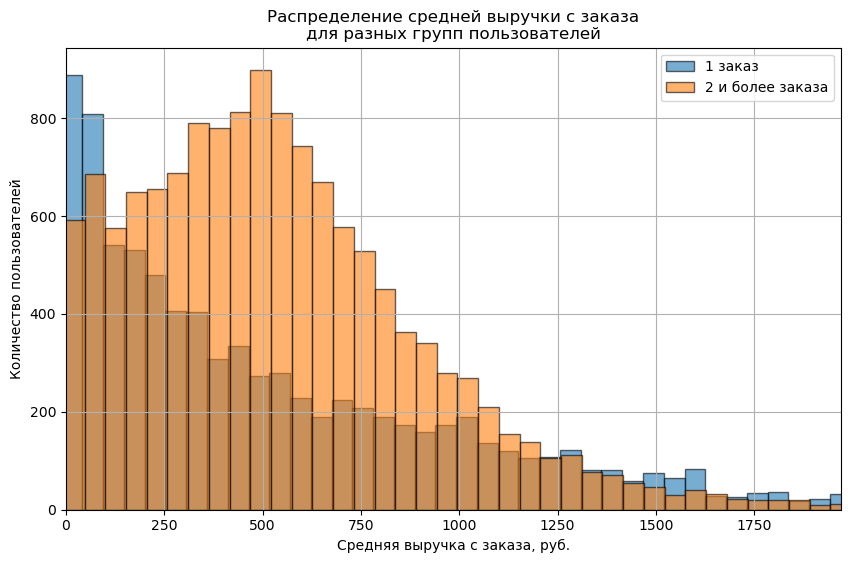

In [72]:
upper_bound = profile_df['avg_revenue'].quantile(0.99)

plt.figure(figsize=(10, 6))

plt.hist(
    one_order_users['avg_revenue'],
    bins=50,
    alpha=0.6,
    label='1 заказ',
    edgecolor='black'
)

plt.hist(
    returned_users['avg_revenue'],
    bins=50,
    alpha=0.6,
    label='2 и более заказа',
    edgecolor='black'
)

plt.xlim(0, upper_bound)

plt.title('Распределение средней выручки с заказа\nдля разных групп пользователей')
plt.xlabel('Средняя выручка с заказа, руб.')
plt.ylabel('Количество пользователей')
plt.legend()
plt.grid()

plt.show()

In [73]:
revenue_compare = (
    profile_df
    .assign(return_group=np.where(profile_df['orders_count'] == 1, '1 заказ', '2 и более заказа'))
    .groupby('return_group')
    .agg(
        users_count=('user_id', 'nunique'),
        mean_avg_revenue=('avg_revenue', 'mean'),
        median_avg_revenue=('avg_revenue', 'median'),
        q25_avg_revenue=('avg_revenue', lambda x: x.quantile(0.25)),
        q75_avg_revenue=('avg_revenue', lambda x: x.quantile(0.75))
    )
    .reset_index()
)

revenue_compare

,return_group,users_count,mean_avg_revenue,median_avg_revenue,q25_avg_revenue,q75_avg_revenue
0,1 заказ,8367,545.04,377.32,132.06,828.36
1,2 и более заказа,13370,543.85,496.38,272.29,741.99


**Промежуточный вывод**

Пользователи были разделены на две группы: совершившие 1 заказ и совершившие 2 и более заказов. Для них были сравнены распределения показателя `avg_revenue`.

Визуально распределения в целом похожи: в обеих группах основная масса пользователей сосредоточена в нижней и средней части диапазона значений, а распределения имеют правый хвост. При этом у пользователей с 1 заказом разброс значений заметно выше: стандартное отклонение составляет 519.48 против 368.10 у вернувшихся пользователей. Это также видно по более широкому диапазону и более выраженному хвосту на гистограмме.

Средние значения в группах практически совпадают: 545.04 руб. у пользователей с одним заказом и 543.85 руб. у пользователей с двумя и более заказами. Это говорит о том, что по среднему значению `avg_revenue` группы почти не различаются.

Однако медианы отличаются сильнее: у пользователей с 1 заказом медиана равна 377.32 руб., а у пользователей с 2 и более заказами — 496.38 руб. Кроме того, нижний квартиль у вернувшихся пользователей выше (272.29 против 132.06), а верхний квартиль, наоборот, немного ниже (741.99 против 828.36). Это означает, что у пользователей, совершивших повторные заказы, значения avg_revenue более сконцентрированы в среднем диапазоне, тогда как у пользователей с одним заказом распределение сильнее растянуто: среди них больше как очень низких, так и очень высоких значений.

Таким образом, средняя выручка с заказа сама по себе не даёт явного разделения между вернувшимися и невернувшимися пользователями, так как средние значения почти одинаковы. Тем не менее по медиане и квартилям видно, что у вернувшихся пользователей avg_revenue в целом более устойчив и сосредоточен вокруг средних значений, тогда как у пользователей с одним заказом разброс выше. Следовательно, связь между `avg_revenue` и повторной покупкой может присутствовать, но она не выглядит сильной и однозначной.

Ещё одна полезная деталь: минимальные значения `avg_revenue` в обеих группах отрицательные. Это может быть связано с возвратами или корректировками.


**Задача 4.2.2.**

Сравните распределение по средней выручке с заказа в двух группах пользователей:
- совершившие 2–4 заказа;
- совершившие 5 и более заказов.

Ответьте на вопрос: есть ли различия по значению средней выручки с заказа между пользователями этих двух групп?

In [74]:
orders_2_4 = profile_df[(profile_df['orders_count'] >= 2) & (profile_df['orders_count'] <= 4)]
orders_5_plus = profile_df[profile_df['orders_count'] >= 5]

print('Пользователи с 2–4 заказами:', len(orders_2_4))
print('Пользователи с 5 и более заказами:', len(orders_5_plus))
print()

print('Статистика avg_revenue для пользователей с 2–4 заказами:')
display(orders_2_4['avg_revenue'].describe())

print('\nСтатистика avg_revenue для пользователей с 5 и более заказами:')
display(orders_5_plus['avg_revenue'].describe())

Пользователи с 2–4 заказами: 7143
Пользователи с 5 и более заказами: 6227

Статистика avg_revenue для пользователей с 2–4 заказами:


count   7143.00
mean     551.28
std      420.24
min       -5.38
25%      218.32
50%      470.99
75%      798.04
max     2628.42
Name: avg_revenue, dtype: float64


Статистика avg_revenue для пользователей с 5 и более заказами:


count   6227.00
mean     535.32
std      297.05
min        0.00
25%      332.93
50%      513.23
75%      696.19
max     2299.87
Name: avg_revenue, dtype: float64

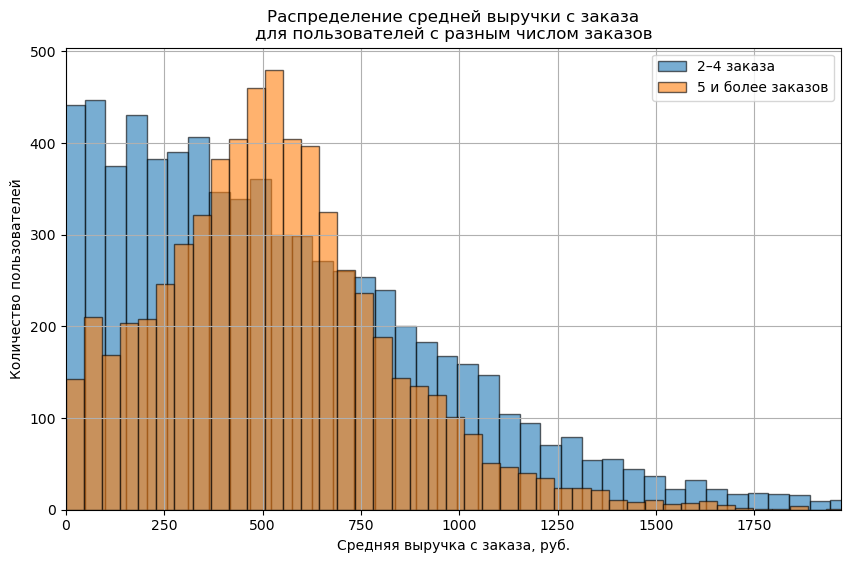

In [75]:
upper_bound = profile_df['avg_revenue'].quantile(0.99)

plt.figure(figsize=(10, 6))

plt.hist(
    orders_2_4['avg_revenue'],
    bins=50,
    alpha=0.6,
    label='2–4 заказа',
    edgecolor='black'
)

plt.hist(
    orders_5_plus['avg_revenue'],
    bins=50,
    alpha=0.6,
    label='5 и более заказов',
    edgecolor='black'
)

plt.xlim(0, upper_bound)

plt.title('Распределение средней выручки с заказа\nдля пользователей с разным числом заказов')
plt.xlabel('Средняя выручка с заказа, руб.')
plt.ylabel('Количество пользователей')
plt.legend()
plt.grid()

plt.show()

In [76]:
revenue_order_groups = (
    profile_df
    .loc[profile_df['orders_count'] >= 2].copy()
)

revenue_order_groups['orders_group'] = np.where(
    revenue_order_groups['orders_count'] <= 4,
    '2–4 заказа',
    '5 и более заказов'
)

revenue_order_compare = (
    revenue_order_groups
    .groupby('orders_group')
    .agg(
        users_count=('user_id', 'nunique'),
        mean_avg_revenue=('avg_revenue', 'mean'),
        median_avg_revenue=('avg_revenue', 'median'),
        q25_avg_revenue=('avg_revenue', lambda x: x.quantile(0.25)),
        q75_avg_revenue=('avg_revenue', lambda x: x.quantile(0.75))
    )
    .reset_index()
)

revenue_order_compare

,orders_group,users_count,mean_avg_revenue,median_avg_revenue,q25_avg_revenue,q75_avg_revenue
0,2–4 заказа,7143,551.28,470.99,218.32,798.04
1,5 и более заказов,6227,535.32,513.23,332.93,696.19


**Промежуточный вывод**

Для пользователей, совершивших 2–4 заказа, и пользователей, совершивших 5 и более заказов, были сравнены распределения показателя `avg_revenue`. Средние значения в группах близки: 551.28 руб. для пользователей с 2–4 заказами и 535.32 руб. для пользователей с 5 и более заказами. Это говорит о том, что по среднему значению заметного различия между группами не наблюдается.

При этом медиана у пользователей с 5 и более заказами выше: 513.23 руб. против 470.99 руб. Кроме того, у этой группы выше нижний квартиль и ниже верхний квартиль, что указывает на более компактное распределение значений `avg_revenue`. Напротив, у пользователей с 2–4 заказами разброс значений шире.

Таким образом, существенного различия по средней выручке с заказа между пользователями двух групп не выявлено, однако у пользователей с 5 и более заказами значения `avg_revenue` более устойчиво сосредоточены в среднем диапазоне. Это может говорить о более стабильном характере заказов у наиболее лояльных пользователей.

**Задача 4.2.3.**

Проанализируйте влияние среднего количества билетов в заказе на вероятность повторной покупки.
- Изучите распределение пользователей по среднему количеству билетов в заказе и опишите основные наблюдения.
- Разделите пользователей на несколько сегментов по среднему количеству билетов в заказе:
  - от 1 до 2 билетов;
  - от 2 до 3 билетов;
  - от 3 до 5 билетов;
  - от 5 и более билетов.
- Для каждого сегмента подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы.
- Ответьте на вопросы:
  - Как распределены пользователи по сегментам — равномерно или сконцентрировано?
  - Есть ли сегменты с аномально высокой или низкой долей повторных покупок?

In [77]:
profile_df['avg_tickets'].describe()

count   21737.00
mean        2.74
std         0.90
min         1.00
25%         2.00
50%         2.75
75%         3.08
max         6.00
Name: avg_tickets, dtype: float64

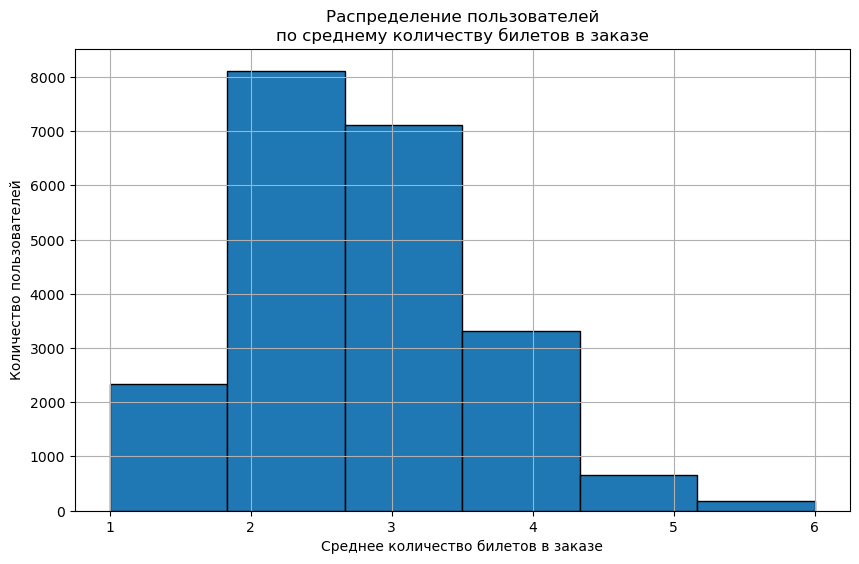

In [78]:
plt.figure(figsize=(10, 6))

plt.hist(
    profile_df['avg_tickets'],
    bins=6,
    edgecolor='black'
)

plt.title('Распределение пользователей\nпо среднему количеству билетов в заказе')
plt.xlabel('Среднее количество билетов в заказе')
plt.ylabel('Количество пользователей')
plt.grid()

plt.show()

In [79]:
profile_df['tickets_segment'] = pd.cut(
    profile_df['avg_tickets'],
    bins=[1, 2, 3, 5, np.inf],
    labels=['1–2 билета', '2–3 билета', '3–5 билетов', '5 и более билетов'],
    right=False,
    include_lowest=True
)

profile_df[['avg_tickets', 'tickets_segment']].head()

,avg_tickets,tickets_segment
0,4.00,3–5 билетов
1,3.00,3–5 билетов
2,2.67,2–3 билета
3,4.00,3–5 билетов
4,1.50,1–2 билета


In [80]:
tickets_segments = (
    profile_df
    .groupby('tickets_segment')
    .agg(
        users_count=('user_id', 'nunique'),
        returned_users=('is_two', 'sum'),
        return_rate=('is_two', 'mean')
    )
    .reset_index()
)

tickets_segments['users_share'] = tickets_segments['users_count'] / tickets_segments['users_count'].sum()
tickets_segments['users_share_pct'] = (tickets_segments['users_share'] * 100).round(2)
tickets_segments['return_rate_pct'] = (tickets_segments['return_rate'] * 100).round(2)

tickets_segments

,tickets_segment,users_count,returned_users,return_rate,users_share,users_share_pct,return_rate_pct
0,1–2 билета,2420,1242,0.51,0.11,11.13,51.32
1,2–3 билета,9605,7096,0.74,0.44,44.19,73.88
2,3–5 билетов,9064,4917,0.54,0.42,41.70,54.25
3,5 и более билетов,648,115,0.18,0.03,2.98,17.75


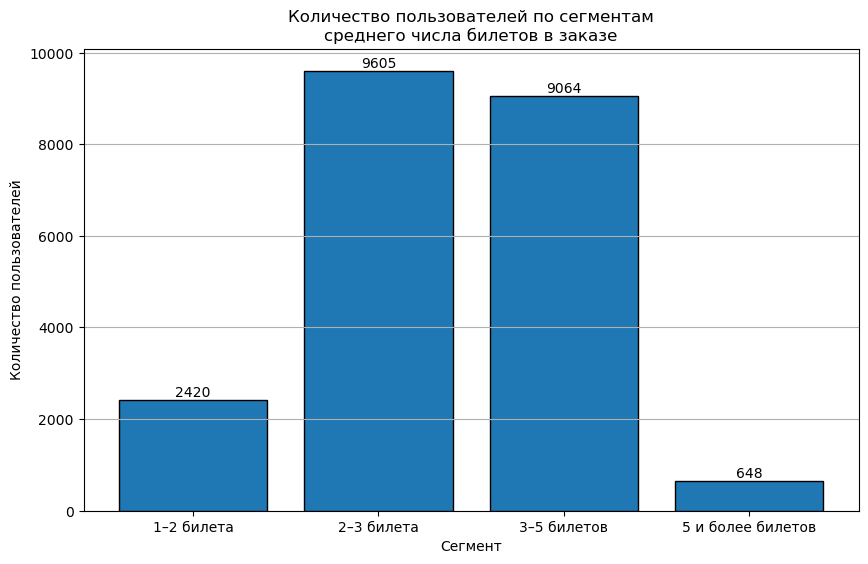

In [81]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    tickets_segments['tickets_segment'],
    tickets_segments['users_count'],
    edgecolor='black'
)

for bar, value in zip(bars, tickets_segments['users_count']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{value}',
        ha='center',
        va='bottom'
    )

plt.title('Количество пользователей по сегментам\nсреднего числа билетов в заказе')
plt.xlabel('Сегмент')
plt.ylabel('Количество пользователей')
plt.grid(axis='y')

plt.show()

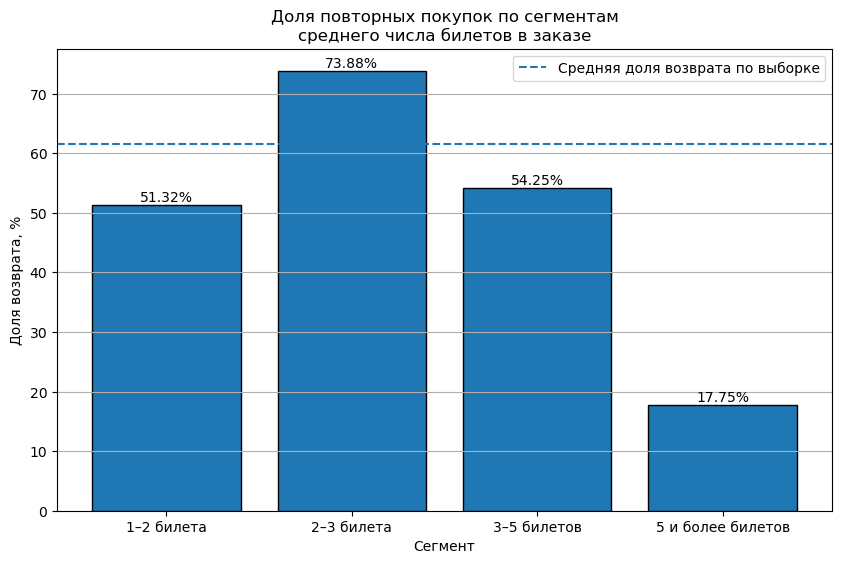

In [82]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    tickets_segments['tickets_segment'],
    tickets_segments['return_rate_pct'],
    edgecolor='black'
)

for bar, value in zip(bars, tickets_segments['return_rate_pct']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{value:.2f}%',
        ha='center',
        va='bottom'
    )

plt.axhline(
    profile_df['is_two'].mean() * 100,
    linestyle='--',
    label='Средняя доля возврата по выборке'
)

plt.title('Доля повторных покупок по сегментам\nсреднего числа билетов в заказе')
plt.xlabel('Сегмент')
plt.ylabel('Доля возврата, %')
plt.legend()
plt.grid(axis='y')

plt.show()

**Промежуточный вывод**

Распределение пользователей по среднему количеству билетов в заказе является неравномерным. Основная часть пользователей сосредоточена в сегментах 2–3 билета и 3–5 билетов, на которые приходится 44.19% и 41.70% выборки соответственно. Сегмент пользователей с 1–2 билетами заметно меньше (11.13%), а сегмент с 5 и более билетами является самым малочисленным (2.98%).

По доле повторных покупок сегменты различаются достаточно сильно. Наиболее высокая доля возврата наблюдается у пользователей со средним числом билетов от 2 до 3 — 73.88%. Это не только максимальное значение среди всех сегментов, но и результат в крупнейшей группе пользователей, что делает его особенно значимым. Сегменты 1–2 билета и 3–5 билетов показывают более умеренные значения — 51.32% и 54.25% соответственно.

Наиболее низкая доля повторных покупок наблюдается в сегменте 5 и более билетов — 17.75%. Однако этот сегмент малочисленный, поэтому его следует интерпретировать с осторожностью.

Таким образом, пользователи распределены по сегментам сконцентрированно, а не равномерно, и среди них действительно есть сегменты с аномально высокой и низкой долей повторных покупок. Наиболее перспективным с точки зрения удержания выглядит сегмент пользователей со средним количеством билетов от 2 до 3, тогда как сегмент 5 и более билетов демонстрирует наименьшую вероятность повторной покупки.

**4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки**

Изучите временные параметры, связанные с первым заказом пользователей:
- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

**Задача 4.3.1.**

Проанализируйте, как день недели, в который была совершена первая покупка, влияет на поведение пользователей.
- По данным даты первого заказа выделите день недели.
- Для каждого дня недели подсчитайте общее число пользователей и долю пользователей, совершивших повторные заказы. Результаты визуализируйте.
- Ответьте на вопрос: влияет ли день недели, в которую совершена первая покупка, на вероятность возврата клиента?

**Решение 4.3.1.**

Для проведения анализа построим карту дней недели на русском языке и составить таблицу дней недели с данными о:
- количестве пользователей, делающих первый заказ,
- количестве пользователей, делающих повторный заказ,
- доли пользователей, первая покупка которых пришлась на этот день недели, среди всех пользователей,
- переведённые значения предыдущих двух столбцов в процентный вид.

После этого сделаем визуализацию

In [83]:
weekday_map = {
    'Monday': 'Понедельник',
    'Tuesday': 'Вторник',
    'Wednesday': 'Среда',
    'Thursday': 'Четверг',
    'Friday': 'Пятница',
    'Saturday': 'Суббота',
    'Sunday': 'Воскресенье'
}

weekday_order = [
    'Понедельник',
    'Вторник',
    'Среда',
    'Четверг',
    'Пятница',
    'Суббота',
    'Воскресенье'
]

profile_df['first_order_weekday'] = (
    profile_df['first_order']
    .dt.day_name()
    .map(weekday_map)
)

profile_df['first_order_weekday'] = pd.Categorical(
    profile_df['first_order_weekday'],
    categories=weekday_order,
    ordered=True
)

weekday_returns = (
    profile_df
    .groupby('first_order_weekday', observed=False)
    .agg(
        users_count=('user_id', 'nunique'),
        returned_users=('is_two', 'sum'),
        return_rate=('is_two', 'mean')
    )
    .reset_index()
)

weekday_returns['users_share'] = weekday_returns['users_count'] / weekday_returns['users_count'].sum()
weekday_returns['users_share_pct'] = (weekday_returns['users_share'] * 100).round(2)
weekday_returns['return_rate_pct'] = (weekday_returns['return_rate'] * 100).round(2)

weekday_returns

,first_order_weekday,users_count,returned_users,return_rate,users_share,users_share_pct,return_rate_pct
0,Понедельник,2941,1858,0.63,0.14,13.53,63.18
1,Вторник,3189,1977,0.62,0.15,14.67,61.99
2,Среда,3071,1914,0.62,0.14,14.13,62.32
3,Четверг,3118,1856,0.60,0.14,14.34,59.53
4,Пятница,3260,1951,0.60,0.15,15.00,59.85
5,Суббота,3363,2128,0.63,0.15,15.47,63.28
6,Воскресенье,2795,1686,0.60,0.13,12.86,60.32


Визуализация количество пользователей по дню недели первой покупки:

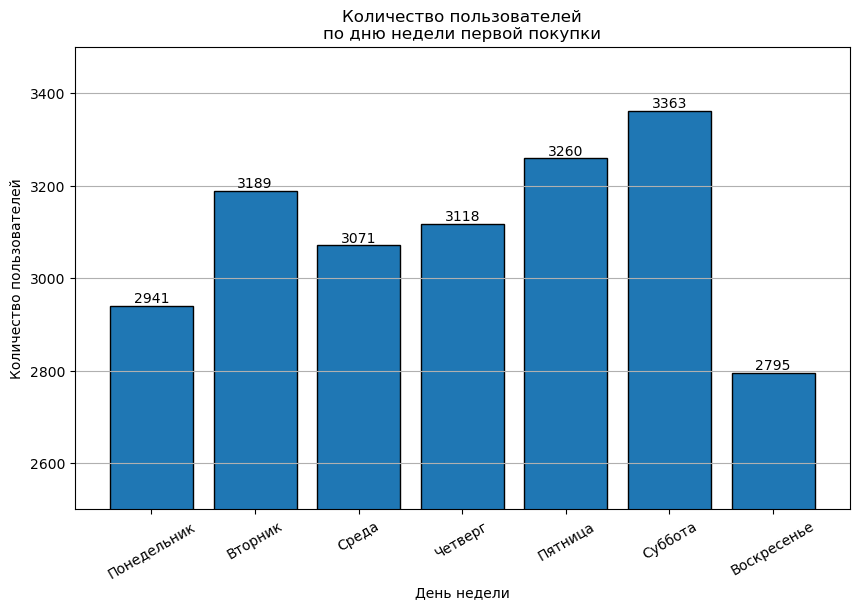

In [84]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    weekday_returns['first_order_weekday'],
    weekday_returns['users_count'],
    edgecolor='black'
)

for bar, value in zip(bars, weekday_returns['users_count']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{value}',
        ha='center',
        va='bottom'
    )

plt.title('Количество пользователей\nпо дню недели первой покупки')
plt.xlabel('День недели')
plt.ylabel('Количество пользователей')
plt.xticks(rotation=30)
plt.ylim(2500, 3500)
plt.grid(axis='y')
plt.show()

Визуализация доли вернувшихся пользователей по дню недели первого заказа:

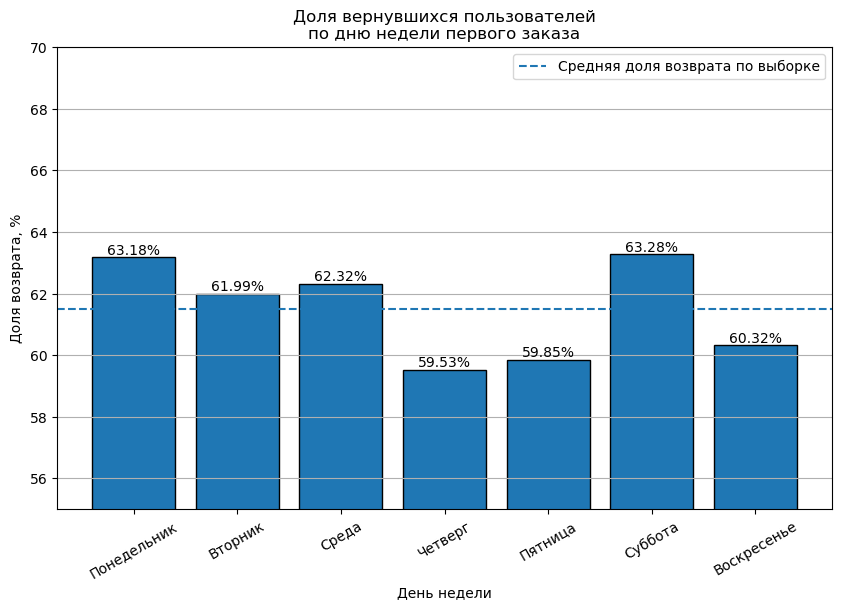

In [85]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    weekday_returns['first_order_weekday'],
    weekday_returns['return_rate_pct'],
    edgecolor='black'
)

for bar, value in zip(bars, weekday_returns['return_rate_pct']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{value:.2f}%',
        ha='center',
        va='bottom'
    )

plt.axhline(
    profile_df['is_two'].mean() * 100,
    linestyle='--',
    label='Средняя доля возврата по выборке'
)

plt.title('Доля вернувшихся пользователей\nпо дню недели первого заказа')
plt.xlabel('День недели')
plt.ylabel('Доля возврата, %')
plt.xticks(rotation=30)
plt.ylim(55, 70)
plt.legend()
plt.grid(axis='y')
plt.show()

**Промежуточный вывод**

Распределение пользователей по дням недели первой покупки в целом довольно равномерное, но немного больше первых заказов приходится на пятницу и субботу, а меньше всего - на воскресенье.

Доля вернувшихся пользователей по дням недели различается не очень сильно: значения колеблются примерно от 59.5% до 63.3% при среднем уровне по выборке около 61.5%. Самая высокая доля возврата наблюдается у пользователей, сделавших первый заказ в субботу и понедельник, а самая низкая - в четверг и пятницу.

Таким образом, день недели первого заказа не выглядит сильным фактором возврата, хотя небольшие различия между сегментами всё же есть. Наиболее интересным днём выглядит суббота, так как на неё приходится и наибольшее число первых заказов, и одна из самых высоких долей возврата.

**Задача 4.3.2.**

Изучите, как средний интервал между заказами влияет на удержание клиентов.
- Рассчитайте среднее время между заказами для двух групп пользователей:
  - совершившие 2–4 заказа;
  - совершившие 5 и более заказов.
- Исследуйте, как средний интервал между заказами влияет на вероятность повторного заказа, и сделайте выводы.

In [86]:
orders_2_4_interval = profile_df[
    (profile_df['orders_count'] >= 2) & (profile_df['orders_count'] <= 4)
]

orders_5_plus_interval = profile_df[
    profile_df['orders_count'] >= 5
]

print('Пользователи с 2–4 заказами:', len(orders_2_4_interval))
print('Пользователи с 5 и более заказами:', len(orders_5_plus_interval))
print()

print('Статистика avg_days_prev для пользователей с 2–4 заказами:')
display(orders_2_4_interval['avg_days_prev'].describe())

print('\nСтатистика avg_days_prev для пользователей с 5 и более заказами:')
display(orders_5_plus_interval['avg_days_prev'].describe())

interval_compare = (
    profile_df
    .loc[profile_df['orders_count'] >= 2]
    .assign(
        orders_group=np.where(
            profile_df.loc[profile_df['orders_count'] >= 2, 'orders_count'] <= 4,
            '2–4 заказа',
            '5 и более заказов'
        )
    )
    .groupby('orders_group')
    .agg(
        users_count=('user_id', 'nunique'),
        mean_avg_days_prev=('avg_days_prev', 'mean'),
        median_avg_days_prev=('avg_days_prev', 'median'),
        q25_avg_days_prev=('avg_days_prev', lambda x: x.quantile(0.25)),
        q75_avg_days_prev=('avg_days_prev', lambda x: x.quantile(0.75))
    )
    .reset_index()
)

interval_compare

Пользователи с 2–4 заказами: 7143
Пользователи с 5 и более заказами: 6227

Статистика avg_days_prev для пользователей с 2–4 заказами:


count   7143.00
mean      21.30
std       28.46
min        0.00
25%        0.00
50%        9.00
75%       34.00
max      148.00
Name: avg_days_prev, dtype: float64


Статистика avg_days_prev для пользователей с 5 и более заказами:


count   6227.00
mean       9.74
std        7.83
min        0.00
25%        3.66
50%        7.92
75%       14.00
max       37.50
Name: avg_days_prev, dtype: float64

,orders_group,users_count,mean_avg_days_prev,median_avg_days_prev,q25_avg_days_prev,q75_avg_days_prev
0,2–4 заказа,7143,21.30,9.00,0.00,34.00
1,5 и более заказов,6227,9.74,7.92,3.66,14.00


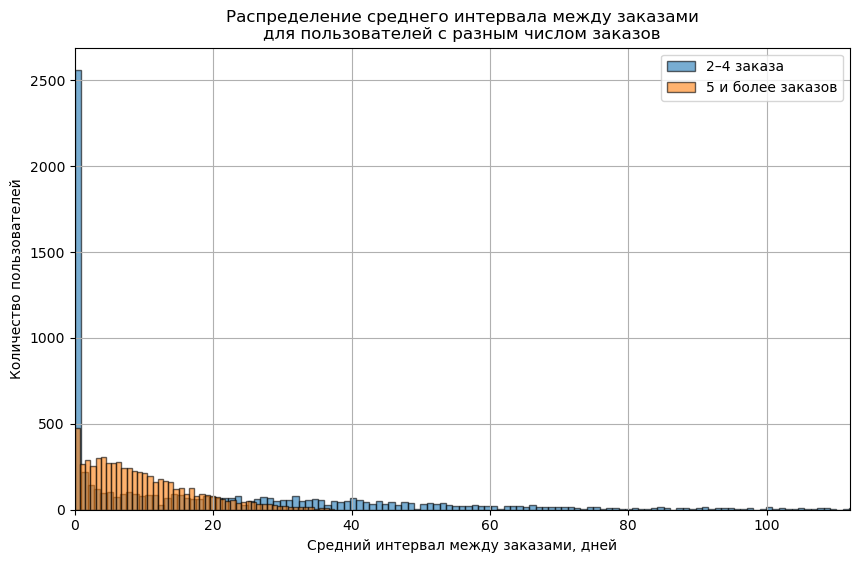

In [87]:
upper_bound = profile_df.loc[profile_df['orders_count'] >= 2, 'avg_days_prev'].quantile(0.99)

plt.figure(figsize=(10, 6))

plt.hist(
    orders_2_4_interval['avg_days_prev'],
    bins=160,
    alpha=0.6,
    label='2–4 заказа',
    edgecolor='black'
)

plt.hist(
    orders_5_plus_interval['avg_days_prev'],
    bins=50,
    alpha=0.6,
    label='5 и более заказов',
    edgecolor='black'
)

plt.xlim(0, upper_bound)

plt.title('Распределение среднего интервала между заказами\nдля пользователей с разным числом заказов')
plt.xlabel('Средний интервал между заказами, дней')
plt.ylabel('Количество пользователей')
plt.legend()
plt.grid()

plt.show()

,avg_days_segment,users_count,loyal_users,loyal_rate,users_share,users_share_pct,loyal_rate_pct
0,до 7 дней,6113,2779,0.45,0.46,45.72,45.46
1,7–14 дней,2496,1887,0.76,0.19,18.67,75.60
2,14–30 дней,2583,1426,0.55,0.19,19.32,55.21
3,30 и более дней,2178,135,0.06,0.16,16.29,6.20


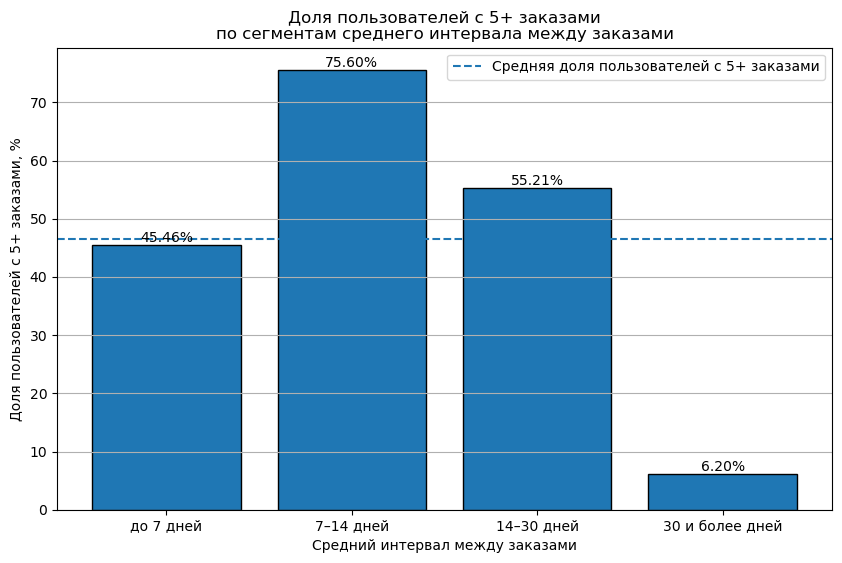

In [88]:
returned_users_df = profile_df[profile_df['orders_count'] >= 2].copy()

returned_users_df['avg_days_segment'] = pd.cut(
    returned_users_df['avg_days_prev'],
    bins=[0, 7, 14, 30, np.inf],
    labels=['до 7 дней', '7–14 дней', '14–30 дней', '30 и более дней'],
    right=False,
    include_lowest=True
)

interval_segments = (
    returned_users_df
    .groupby('avg_days_segment', observed=False)
    .agg(
        users_count=('user_id', 'nunique'),
        loyal_users=('is_five', 'sum'),
        loyal_rate=('is_five', 'mean')
    )
    .reset_index()
)

interval_segments['users_share'] = interval_segments['users_count'] / interval_segments['users_count'].sum()
interval_segments['users_share_pct'] = (interval_segments['users_share'] * 100).round(2)
interval_segments['loyal_rate_pct'] = (interval_segments['loyal_rate'] * 100).round(2)

display(interval_segments)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    interval_segments['avg_days_segment'],
    interval_segments['loyal_rate_pct'],
    edgecolor='black'
)

for bar, value in zip(bars, interval_segments['loyal_rate_pct']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{value:.2f}%',
        ha='center',
        va='bottom'
    )

plt.axhline(
    returned_users_df['is_five'].mean() * 100,
    linestyle='--',
    label='Средняя доля пользователей с 5+ заказами'
)

plt.title('Доля пользователей с 5+ заказами\nпо сегментам среднего интервала между заказами')
plt.xlabel('Средний интервал между заказами')
plt.ylabel('Доля пользователей с 5+ заказами, %')
plt.legend()
plt.grid(axis='y')

plt.show()

**Промежуточный вывод**

Пользователи с 5 и более заказами совершают покупки чаще, чем пользователи с 2–4 заказами: средний интервал между заказами у них составляет 9.74 дня против 21.30 дня. Распределение у группы 5+ заказов более компактное, тогда как у пользователей с 2–4 заказами интервалы между покупками более растянуты.

При сегментации по среднему интервалу между заказами видно, что самая высокая доля пользователей с 5+ заказами наблюдается в сегменте 7–14 дней — 75.6%. В сегменте 14–30 дней она составляет 55.2%, а при интервале 30 и более дней резко снижается до 6.2%.

Таким образом, средний интервал между заказами связан с удержанием пользователей: чем он меньше, тем выше вероятность, что пользователь совершит много заказов. При этом наиболее благоприятным выглядит интервал от 7 до 14 дней.

**4.4. Корреляционный анализ количества покупок и признаков пользователя**

Изучите, какие характеристики первого заказа и профиля пользователя могут быть связаны с числом покупок. Для этого используйте универсальный коэффициент корреляции `phi_k`, который позволяет анализировать как числовые, так и категориальные признаки.

**Задача 4.4.1**

Проведите корреляционный анализ:
- Рассчитайте коэффициент корреляции `phi_k` между признаками профиля пользователя и числом заказов. При необходимости используйте параметр `interval_cols` для определения интервальных данных.
- Проанализируйте полученные результаты. Если полученные значения будут близки к нулю, проверьте разброс данных в orders_count. Такое возможно, когда в данных преобладает одно значение: в таком случае корреляционный анализ может показать отсутствие связей. Чтобы этого избежать, выделите сегменты пользователей по полю orders_count, а затем повторите корреляционный анализ. Выделите такие сегменты:
  - 1 заказ;
  - от 2 до 4 заказов;
  - от 5 и выше.
- Визуализируйте результат корреляции с помощью тепловой карты.
- Ответьте на вопрос: какие признаки наиболее связаны с количеством заказов?

**Решение 4.4.1.**

In [89]:
print('Статистика orders_count:')
display(profile_df['orders_count'].describe())

correlation_df = profile_df.copy()

correlation_df['lifetime_days'] = (
    correlation_df['last_order'] - correlation_df['first_order']
).dt.days

correlation_df['avg_days_prev_corr'] = correlation_df['avg_days_prev'].fillna(-1)

phik_orders_count_df = correlation_df[
    [
        'first_device',
        'first_region',
        'first_service',
        'first_event_type',
        'first_order_weekday',
        'avg_revenue',
        'avg_tickets',
        'lifetime_days',
        'avg_days_prev_corr',
        'orders_count'
    ]
]

phik_orders_count = phik_orders_count_df.phik_matrix(
    interval_cols=[
        'avg_revenue',
        'avg_tickets',
        'lifetime_days',
        'avg_days_prev_corr',
        'orders_count'
    ]
)

orders_count_corr = (
    phik_orders_count['orders_count']
    .drop('orders_count')
    .sort_values(ascending=False)
    .reset_index()
)

orders_count_corr.columns = ['feature', 'phik_with_orders_count']
print('\nКоэффициенты корреляции признаков с количеством заказов')
orders_count_corr

Статистика orders_count:


count   21737.00
mean        7.55
std        20.96
min         1.00
25%         1.00
50%         2.00
75%         5.00
max       315.00
Name: orders_count, dtype: float64


Коэффициенты корреляции признаков с количеством заказов


,feature,phik_with_orders_count
0,lifetime_days,0.56
1,avg_tickets,0.30
2,avg_revenue,0.18
3,avg_days_prev_corr,0.10
4,first_region,0.08
5,first_order_weekday,0.07
6,first_service,0.06
7,first_device,0.02
8,first_event_type,0.00


In [90]:
correlation_df['orders_group'] = np.where(
    correlation_df['orders_count'] == 1,
    '1 заказ',
    np.where(
        correlation_df['orders_count'] <= 4,
        '2–4 заказа',
        '5 и более заказов'
    )
)

phik_orders_group_df = correlation_df[
    [
        'first_device',
        'first_region',
        'first_service',
        'first_event_type',
        'first_order_weekday',
        'avg_revenue',
        'avg_tickets',
        'lifetime_days',
        'avg_days_prev_corr',
        'orders_group'
    ]
]

phik_orders_group = phik_orders_group_df.phik_matrix(
    interval_cols=[
        'avg_revenue',
        'avg_tickets',
        'lifetime_days',
        'avg_days_prev_corr'
    ]
)

orders_group_corr = (
    phik_orders_group['orders_group']
    .drop('orders_group')
    .sort_values(ascending=False)
    .reset_index()
)

orders_group_corr.columns = ['feature', 'phik_with_orders_group']
print('Коэффициенты корреляции признаков с группами по количеству заказов')
orders_group_corr

Коэффициенты корреляции признаков с группами по количеству заказов


,feature,phik_with_orders_group
0,lifetime_days,0.73
1,avg_tickets,0.59
2,avg_days_prev_corr,0.54
3,avg_revenue,0.33
4,first_region,0.12
5,first_service,0.08
6,first_event_type,0.04
7,first_order_weekday,0.04
8,first_device,0.02


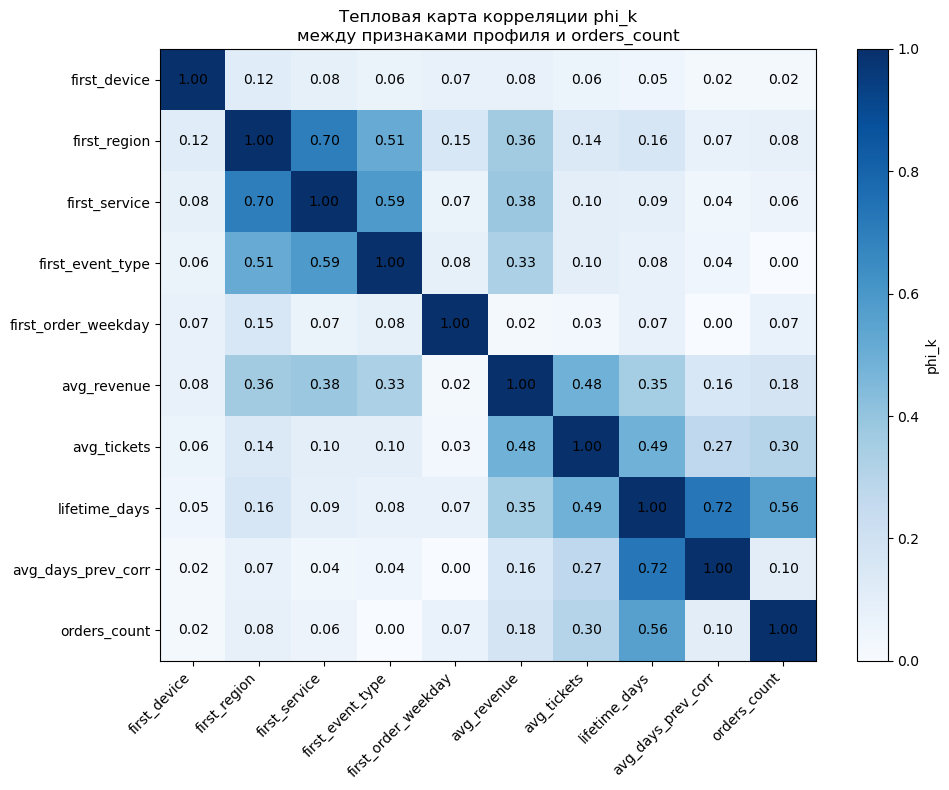

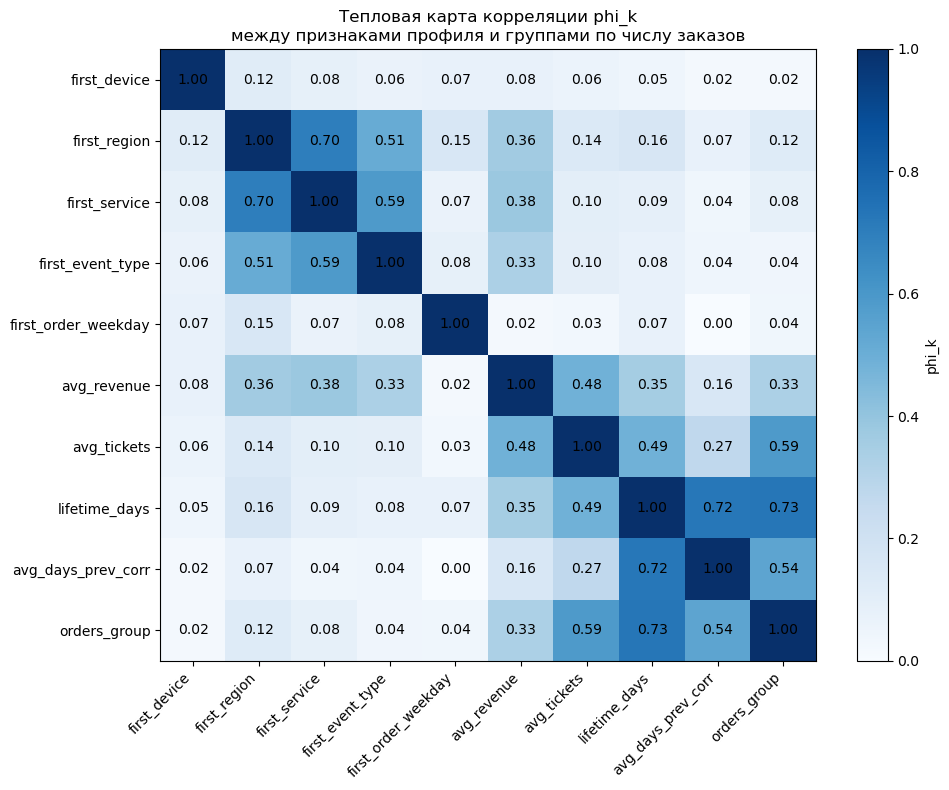

In [91]:
def plot_phik_heatmap(matrix, title):
    plt.figure(figsize=(10, 8))
    plt.imshow(matrix, cmap='Blues', aspect='auto', vmin=0, vmax=1)

    plt.xticks(
        range(len(matrix.columns)),
        matrix.columns,
        rotation=45,
        ha='right'
    )
    plt.yticks(
        range(len(matrix.index)),
        matrix.index
    )

    for i in range(len(matrix.index)):
        for j in range(len(matrix.columns)):
            plt.text(
                j,
                i,
                f'{matrix.iloc[i, j]:.2f}',
                ha='center',
                va='center'
            )

    plt.title(title)
    plt.colorbar(label='phi_k')
    plt.tight_layout()
    plt.show()


plot_phik_heatmap(
    phik_orders_count,
    'Тепловая карта корреляции phi_k\nмежду признаками профиля и orders_count'
)

plot_phik_heatmap(
    phik_orders_group,
    'Тепловая карта корреляции phi_k\nмежду признаками профиля и группами по числу заказов'
)

**Промежуточный вывод**

Корреляционный анализ показал, что наибольшая связь с количеством заказов наблюдается у признака `lifetime_days`: коэффициент phi_k с `orders_count` составляет 0.56, а при переходе к сегментам по числу заказов — 0.73. Это означает, что чем дольше пользователь остаётся активным на платформе, тем выше вероятность, что он совершит больше заказов.

Среди остальных признаков наиболее заметную связь показывают `avg_tickets` и `avg_days_prev_corr`. Среднее число билетов в заказе связано с числом заказов умеренно: 0.30 для `orders_count` и 0.59 для сегментов по числу заказов. Средний интервал между заказами слабо связан с сырым количеством заказов (0.10), но заметно сильнее — с сегментами пользователей (0.54), что подтверждает вывод из предыдущей задачи о важности частоты покупок для удержания.

Признак `avg_revenue` показывает слабую или умеренную связь: 0.18 с `orders_count` и 0.33 с сегментами. Это говорит о том, что средняя выручка с заказа связана с количеством покупок слабее, чем временные характеристики и среднее число билетов.

Категориальные признаки первого заказа - `first_region`, `first_service`, `first_event_type`, `first_order_weekday` и особенно `first_device` - демонстрируют слабую связь с количеством заказов. Наиболее заметен здесь только `first_region`, но и его коэффициент остаётся невысоким: 0.08 для `orders_count` и 0.12 для групп по числу заказов.

Дополнительная сегментация пользователей по числу заказов оказалась полезной: связи стали выражены сильнее и интерпретируются понятнее. Это связано с тем, что распределение `orders_count` неоднородно: медиана равна 2, а 75-й перцентиль — 5, при этом максимум достигает 315, то есть распределение сильно скошено вправо.

Таким образом, наиболее связанными с количеством заказов признаками являются `lifetime_days`, `avg_tickets` и `avg_days_prev_corr`. Именно временные и поведенческие характеристики пользователя оказываются важнее, чем признаки первого заказа.

#### Шаг 5. Общие выводы и рекомендации

В ходе проекта были проанализированы данные Яндекс Афиши на уровне заказов пользователей. Исходный датасет содержал 290 611 строк и 15 столбцов, занимая около 83.3 МБ памяти. В нём были представлены данные о пользователях, заказах, выручке, количестве билетов, времени между покупками, а также о мероприятиях, сервисах и регионах.

***Предобработка***

На этапе предобработки выручка была приведена к единой валюте: значения в тенге переведены в рубли, после чего сформирован столбец `revenue_rub`. Были оптимизированы типы данных, а также исследованы числовые признаки `revenue_rub` и `tickets_count`. Из-за наличия выбросов в правом хвосте распределений была применена фильтрация по верхнему 99-му процентилю. В результате число строк сократилось до 287 606, а объём памяти уменьшился до 75.8 МБ, то есть удалось сэкономить около 7.5 МБ. Также отдельно было отмечено наличие отрицательных значений выручки, что может быть связано с возвратами или корректировками.

***Профили пользователей***

Далее была сформирована таблица профилей пользователей `profile_df`, где для каждого пользователя были собраны характеристики первого заказа, количество заказов, средняя выручка, среднее число билетов и средний интервал между покупками. После удаления экстремальных значений по `orders_count` в профиле осталось 21 737 пользователей. Это позволило перейти от анализа отдельных заказов к анализу поведения пользователей.

***Исследовательский анализ данных***

Исследование показало, что доля пользователей с 2 и более заказами составляет около 61.5%, а доля пользователей с 5 и более заказами — около 29%. Это говорит о наличии заметной доли возвратных и лояльных пользователей.

В разрезе признаков первого заказа различия в удержании оказались умеренными. Пользователи, начавшие с концертов, театра и выставок, в среднем возвращаются чаще, чем пользователи, начавшие со спорта или ёлок. По устройству первого заказа различия минимальны, а по билетным сервисам показатели в целом близки друг к другу. По регионам различия заметнее, причём в более активных регионах доля повторных заказов выше.

Проверка гипотез показала, что гипотеза о более высоком возврате после спортивных мероприятий не подтвердилась: у пользователей спорта возврат ниже, чем у пользователей концертов. Гипотеза о том, что в более активных регионах выше доля повторных заказов, напротив, подтвердилась.

Показатель `avg_revenue` оказался не самым сильным фактором удержания: средняя выручка у разных групп пользователей близка. Гораздо более полезными оказались поведенческие характеристики. Так, наиболее высокий возврат наблюдается у пользователей со средним числом билетов 2–3, причём это ещё и один из самых крупных сегментов. Напротив, сегмент с 5 и более билетами малочисленный и показывает низкую долю возврата.

Слабую связь с удержанием показал день недели первого заказа: различия между днями есть, но они невелики. Намного сильнее проявил себя средний интервал между заказами. У пользователей с 5 и более заказами он существенно ниже, чем у пользователей с 2–4 заказами. Наиболее благоприятным для удержания оказался интервал 7–14 дней, а при интервале 30 и более дней вероятность высокой лояльности резко падает.

Корреляционный анализ `phi_k` подтвердил, что наиболее связаны с количеством заказов признаки `lifetime_days`, `avg_tickets` и `avg_days_prev_corr`. Это означает, что на число покупок сильнее влияют не характеристики первого заказа, а длительность активности пользователя и его поведенческие привычки.

***Основные выводы***

- На удержание сильнее всего влияют поведенческие и временные признаки, а не формальные характеристики первого заказа.
- Наиболее перспективными выглядят пользователи со средним числом билетов 2–3 и интервалом между заказами 7–14 дней.
- Слабее всего с количеством заказов связаны устройство, день недели первого заказа и часть категориальных признаков первого заказа.
- Тип первого мероприятия и регион могут быть полезны для сегментации, но не как главные драйверы удержания.

***Рекомендации***

- Сфокусировать подход к удержанию пользователей на сокращении интервала между заказами, особенно в первые недели после первой покупки.
- Отдельно работать с пользователями, которые не возвращаются дольше 2–4 недель: именно здесь высок риск потери.
- Развивать сценарии удержания для сегмента 2–3 билета, так как он и крупный, и показывает высокий возврат.
- Использовать концерты, театр и выставки как более сильные точки входа для привлечения новой аудитории.
- Не делать основной акцент на устройстве первого заказа, так как его влияние на удержание минимально.
- В региональных стратегиях ориентироваться не только на долю возврата, но и на размер сегмента, чтобы фокусироваться на направлениях с максимальным бизнес-эффектом.

В целом исследование показало, что для роста удержания важно не только привлекать новых пользователей, но и как можно раньше переводить их в сценарий регулярных повторных покупок.